# Quantum circuit complexity — entanglement, magic and spectral statistics of random circuits

**Marcin Płodzień** — Institute of Theoretical Physics, Jagiellonian University in Kraków  
[ORCID 0000-0002-0835-1644](https://orcid.org/0000-0002-0835-1644) · [github.com/MarcinPlodzien](https://github.com/MarcinPlodzien) · [www](https://chaos.if.uj.edu.pl/marcinplodzien/)

*Quantum Many-Body Simulation — Chapter 9 — Entanglement and complexity diagnostics*

## 1. Simulability, resources and complexity

A quantum computer with $N$ qubits carries a state vector with $2^N$ complex amplitudes. Writing them all down is
hopeless for $N=60$, and that is usually where the story of "quantum advantage" stops. But it is the wrong stopping
point, because a classical computer never has to write down all the amplitudes. It only has to *answer the question we
ask*, and for enormous families of states there are shortcuts that answer the question in polynomial time.

Two shortcuts matter most.

* A **matrix product state** stores a state as a chain of small tensors. Its cost is set by the *entanglement* across
  the cuts of the chain rather than by $2^N$. A state with 3 bits of entanglement across every cut costs almost nothing,
  whatever $N$ is.
* A **stabilizer simulator** stores a state as a list of $N$ Pauli operators that leave it invariant. Its cost is
  $O(N)$ per gate and $O(N^2)$ per measurement — *regardless of how entangled the state is*. The Gottesman-Knill
  theorem says that every circuit built from Hadamard, phase and CNOT gates, started in a computational-basis state
  and read out in the computational basis, can be simulated this way, and such circuits routinely produce states with
  the maximal possible entanglement.

So entanglement and hardness are different things, and no other single number captures hardness either. This
notebook is built around one problem:

> **Identify what distinguishes a state that is hard to simulate classically from one that is easy, and measure how a
> circuit generates that hardness as a function of its depth and of its gate set.**

We will run one and the same brick-wall circuit architecture with three different gate sets — Clifford, Clifford
doped with $k$ non-Clifford $T$ gates, and a universal set — and measure four diagnostics on the states they produce:

1. the **half-chain entanglement entropy** $S$ (what a tensor network pays: bond dimension $\chi\ge2^{S}$);
2. the **stabilizer Renyi entropy** $M_2$, a measure of *magic* or non-stabilizerness (what a stabilizer simulator pays);
3. the **entanglement spectrum** — the full set of eigenvalues of the reduced density matrix — its shape (flat or
   Marchenko-Pastur) and the *statistics of its level spacings* (Poisson or Wigner-Dyson);
4. the **output probability distribution** and its anticoncentration (Porter-Thomas or uniform), which is what a
   sampling-based advantage claim rests on.

The main result is measured below: the entanglement entropy alone cannot tell the three gate sets apart, since all
three saturate at essentially the same value, while magic and the entanglement spectrum separate all three, and the
output distribution separates the Clifford family from the other two.

None of these four numbers *is* the quantity called "quantum circuit complexity" (the minimum number of elementary
gates needed to build a state). That quantity is not computable at these sizes; the four diagnostics are proxies, and
Section 2.5 states what is known about the quantity itself.

### What you will learn

**Physics**

* why entanglement, magic and anticoncentration are three *independent* resources, and which classical algorithm each
  of them defeats;
* the theorem that the entanglement spectrum of a stabilizer state is exactly flat, with a proof;
* the Marchenko-Pastur law as the entanglement spectrum of a Haar-random state, and Page's value for its entropy;
* level repulsion: what Poisson and Wigner-Dyson statistics mean for the *entanglement* spectrum, and what "entanglement
  complexity" means in the sense of Chamon, Hamma and Mucciolo;
* Porter-Thomas statistics and why a random Clifford circuit fails the cross-entropy benchmark completely.

**Numerical methods**

* bipartite spectra from a single SVD; the cost $O(2^{3N/2})$ of a half-chain cut;
* the $O(N4^N)$ Walsh-Hadamard algorithm for the stabilizer Renyi entropy;
* level-spacing statistics on a finite spectrum: the gap ratio, why it needs no unfolding, and how to build an
  *uncorrelated surrogate* to calibrate it;
* estimating means over circuit realisations with standard errors, never from one circuit.

**Implementation practice**

* representing a circuit as an *array of gates* and executing it with `lax.scan`, so that the whole circuit compiles
  once instead of being unrolled;
* `jax.vmap` over circuit realisations, with explicit PRNG keys, so that an ensemble costs one batched call;
* validating every new function against an independent reference before using it.

### Prerequisites

* [`01_jax_from_scratch`](../ch01_computational_toolbox/01_jax_from_scratch.ipynb) and
  [`02_einsum_from_scratch`](../ch01_computational_toolbox/02_einsum_from_scratch.ipynb) — `jit`, `vmap`, `lax.scan`,
  PRNG keys, einsum.
* [`06_states_observables_entanglement`](../ch03_matrix_free_engine/06_states_observables_entanglement.ipynb) —
  reduced density matrices, Schmidt decomposition, entanglement entropy.
* [`10_random_unitaries_and_random_circuits`](../ch04_digital_quantum_circuits/10_random_unitaries_and_random_circuits.ipynb) —
  Haar measure, brick-wall circuits, the Clifford group, the Page value, Porter-Thomas statistics, XEB.
* [`27_stabilizer_renyi_entropy`](27_stabilizer_renyi_entropy.ipynb) — the Pauli group, stabilizer states,
  Gottesman-Knill, and the stabilizer Renyi entropy together with its fast algorithm.

Everything those notebooks derived is *used* here; the helper functions we borrow are reproduced in this notebook with
a pointer to where they were derived, so this notebook still runs on its own.

## Configuration

Every notebook of this course starts with the same cell. Choose where to run (`DEVICE`) and the floating-point precision (`PRECISION`): `"double"` = `float64/complex128` (default, recommended for physics), `"single"` = `float32/complex64` (half the memory, faster on consumer GPUs, but watch the round-off). All code below derives its dtypes from `RDTYPE`/`CDTYPE` and its check tolerances from `TOL`, so nothing else needs to change.

In [1]:
# ==============================================================================
# CONFIGURATION  -- adapt to your hardware, then run the notebook top to bottom
# ==============================================================================
DEVICE    = "auto"     # "auto": use a GPU if JAX finds one, else CPU | "cpu" | "gpu"
PRECISION = "double"   # "double": float64/complex128 | "single": float32/complex64

import os
if DEVICE == "cpu":
    os.environ["JAX_PLATFORMS"] = "cpu"          # must be set BEFORE jax is imported

import os
import string
from functools import partial

import math
import numpy as np
import jax
import jax.numpy as jnp
from jax import lax

# Precision is configurable: "double" = float64/complex128 (default; needed for long time evolutions and
# tight validation), "single" = float32/complex64 (half the memory, faster on consumer GPUs).
# In a notebook PRECISION is defined in the Configuration cell; for this module use the env var QE_PRECISION.
PRECISION = globals().get("PRECISION", os.environ.get("QE_PRECISION", "double"))
jax.config.update("jax_enable_x64", PRECISION == "double")
RDTYPE = jnp.float64 if PRECISION == "double" else jnp.float32       # real dtype
CDTYPE = jnp.complex128 if PRECISION == "double" else jnp.complex64  # complex dtype of all states/operators
TOL = 1e-10 if PRECISION == "double" else 1e-4                       # tolerance for sanity checks (asserts)
_LETTERS = string.ascii_letters  # 52 einsum labels; a call needs (axes + new labels) <= 52: apply_gate on a state
                                 # N + k <= 52 (N <= 51 for k = 1), apply_gate_dm 2N + k <= 52 (N <= 25 for k = 1, 2),
                                 # apply_kraus_dm 2N + 2k + 1 <= 52 (N <= 24 for k = 1, N <= 23 for k = 2)

import time
import matplotlib.pyplot as plt

if DEVICE == "gpu" and jax.default_backend() == "cpu":
    print("WARNING: DEVICE='gpu' requested but JAX found no GPU -- running on CPU.")
print(f"JAX {jax.__version__} | backend: {jax.default_backend()} | devices: {jax.devices()}")
print(f"precision: {PRECISION} -> real {RDTYPE.__name__}, complex {CDTYPE.__name__}, check tolerance TOL={TOL:g}")


JAX 0.11.0 | backend: cpu | devices: [CpuDevice(id=0)]
precision: double -> real float64, complex complex128, check tolerance TOL=1e-10


In [2]:
#| code-fold: true
#| code-summary: "Engine recap — the simulator primitives used in this notebook (click to expand)"
# ==============================================================================
# ENGINE RECAP: the functions of quantum_engine.py (SmoQ.jax) used in this notebook.
# Each one is derived, with its mathematics and an independent check, in notebook 08b
# (Chapter 3), 'Building the quantum simulator engine'.
# States are rank-N tensors of shape (2,)*N; every operator acts through ONE einsum.
# ==============================================================================
# ----------------------------------------------------------------------------
# 1. Elementary matrices: Paulis, Clifford generators, rotations
# ----------------------------------------------------------------------------
I2 = jnp.eye(2, dtype=CDTYPE)
X = jnp.array([[0, 1], [1, 0]], dtype=CDTYPE)
Y = jnp.array([[0, -1j], [1j, 0]], dtype=CDTYPE)
Z = jnp.array([[1, 0], [0, -1]], dtype=CDTYPE)
H = jnp.array([[1, 1], [1, -1]], dtype=CDTYPE) / jnp.sqrt(2.0)      # Hadamard: Z-basis <-> X-basis
S = jnp.array([[1, 0], [0, 1j]], dtype=CDTYPE)                      # phase gate, S^2 = Z
SDG = S.conj().T
T = jnp.array([[1, 0], [0, jnp.exp(1j * jnp.pi / 4)]], dtype=CDTYPE)  # pi/8 gate, T^2 = S (non-Clifford!)
PAULI = {"I": I2, "X": X, "Y": Y, "Z": Z}
CNOT = jnp.array([[1, 0, 0, 0], [0, 1, 0, 0], [0, 0, 0, 1], [0, 0, 1, 0]], dtype=CDTYPE)
CZ = jnp.diag(jnp.array([1, 1, 1, -1], dtype=CDTYPE))
def ry(theta):
    """Rotation about y:  Ry(theta) = exp(-i theta Y/2) = [[cos, -sin], [sin, cos]](theta/2)  (real matrix)."""
    c, s = jnp.cos(theta / 2), jnp.sin(theta / 2)
    return jnp.array([[c, -s], [s, c]], dtype=CDTYPE)


# ----------------------------------------------------------------------------
# 2. THE core primitive: a k-qubit operator acting on a tensor through ONE einsum
# ----------------------------------------------------------------------------
def apply_gate(psi, U, qubits):
    """Apply a k-qubit operator U to the axes `qubits` of the tensor `psi`.

    MATH
    ----
    One qubit (k=1), target q:
        psi'[s_0,..,a,..,s_{N-1}] = sum_b  U[a,b] psi[s_0,..,b,..,s_{N-1}]
    Two qubits (k=2), targets (q1,q2); the 4x4 matrix is reshaped to U[a1,a2,b1,b2]:
        psi'[.., a1, .., a2, ..] = sum_{b1,b2} U[a1,a2,b1,b2] psi[.., b1, .., b2, ..]
    This IS the action of (1 x .. x U x .. x 1) -- written without ever building it.

    EINSUM TRANSLATION  (generated automatically below)
    ------------------
        N=3, q=1        :  "db,abc->adc"          d = new (output) index of qubit 1
        N=4, q=(1,3)    :  "efbd,abcd->aecf"      e,f = new indices of qubits 1 and 3
    Recipe: label the axes of psi with letters a,b,c,...; give every target qubit a NEW
    letter (the next unused ones); U carries (new letters)+(old letters of the targets); the
    output is psi's labels with the target letters replaced by the new ones.

    IMPLEMENTATION NOTES
    --------------------
    * reshape of U:  (2^k,2^k) -> (2,)*2k.  Row index = (a1..ak), column = (b1..bk), and
      the FIRST qubit in `qubits` is the most significant bit of the small matrix, i.e. it
      corresponds to the LEFT factor of kron(A,B).
    * `qubits` may be any distinct axes in any order: non-neighbouring gates cost the same.
    * U need not be unitary: projectors, Kraus operators and Hamiltonian terms reuse this.
    * psi may be ANY tensor with those axes of size 2: a state (rank N), a density tensor
      (rank 2N: ket axes 0..N-1, bra axes N..2N-1), ...
    COST   O(2^k * 2^N) operations, O(2^N) memory  (dense matrix: O(4^N) both).
    JAX    `qubits` must be static Python ints (they define the einsum string); psi and U are
           traced, so the function can sit inside jit / grad / vmap / scan.
    """
    qubits = tuple(int(q) for q in qubits)
    k, n = len(qubits), psi.ndim
    U = jnp.asarray(U, dtype=psi.dtype).reshape((2,) * (2 * k))     # matrix -> rank-2k tensor
    inp = list(_LETTERS[:n])                                         # labels of psi's axes
    new = _LETTERS[n:n + k]                                          # fresh labels for the outputs
    out = inp.copy()
    for a, q in zip(new, qubits):
        out[q] = a                                                   # target axes get the new labels
    sub = f"{''.join(new)}{''.join(inp[q] for q in qubits)},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, U, psi)


# ----------------------------------------------------------------------------
# 3. State preparation
# ----------------------------------------------------------------------------
def zero_state(N):
    """|00...0>: a rank-N tensor of zeros with a single 1 at index (0,0,...,0).
    JAX arrays are immutable: `.at[idx].set(v)` returns an updated COPY (functional style)."""
    return jnp.zeros((2,) * N, dtype=CDTYPE).at[(0,) * N].set(1.0)

_KETS = {"0": [1, 0], "1": [0, 1], "+": [1, 1], "-": [1, -1], "r": [1, 1j], "l": [1, -1j]}
def product_state(spec):
    """Product state from a string, one character per qubit:  product_state('01+-') = |0>|1>|+>|->.
    ('r','l' = the +1/-1 eigenstates of Y.)

    MATH    psi[s_0,...,s_{N-1}] = v0[s_0] v1[s_1] ... v_{N-1}[s_{N-1}]
    EINSUM  an outer product = einsum with NO summed index:  "a,b,c->abc".
    A product state needs only 2N numbers; entanglement is what makes all 2^N necessary.
    """
    vecs = [jnp.array(_KETS[c], dtype=CDTYPE) / jnp.linalg.norm(jnp.array(_KETS[c], dtype=CDTYPE))
            for c in spec]
    n = len(vecs)
    sub = ",".join(_LETTERS[i] for i in range(n)) + "->" + _LETTERS[:n]
    return jnp.einsum(sub, *vecs)

def ghz_state(N):
    """GHZ state (|0...0> + |1...1>)/sqrt(2): two non-zero entries of the rank-N tensor."""
    psi = jnp.zeros((2,) * N, dtype=CDTYPE)
    return psi.at[(0,) * N].set(1 / jnp.sqrt(2.0)).at[(1,) * N].set(1 / jnp.sqrt(2.0))

def cluster_state(N, periodic=False):
    """1D cluster (graph) state: |+>^N followed by CZ on every bond.  Stabilisers K_i = Z_{i-1} X_i Z_{i+1}."""
    psi = product_state("+" * N)
    for q in range(N - 1):
        psi = apply_gate(psi, CZ, [q, q + 1])
    if periodic and N > 2:
        psi = apply_gate(psi, CZ, [N - 1, 0])
    return psi

def haar_state(key, N):
    """Haar-random pure state: a complex Gaussian vector, normalised.
    (The Gaussian measure is unitarily invariant, so the direction is uniformly distributed.)
    `key` is an explicit JAX PRNG key -- same key, same state: reproducible science."""
    k1, k2 = jax.random.split(key)
    v = jax.random.normal(k1, (2,) * N) + 1j * jax.random.normal(k2, (2,) * N)
    return (v / jnp.linalg.norm(v)).astype(CDTYPE)

def normalize(psi):
    """psi / ||psi||  (Frobenius norm of the tensor = 2-norm of the state vector)."""
    return psi / jnp.linalg.norm(psi)


# ----------------------------------------------------------------------------
# 4. Reduced density matrices & observables (matrix-free)
# ----------------------------------------------------------------------------
def rdm(psi, keep):
    """Reduced density matrix of the qubits `keep` from a PURE state:  rho_A = Tr_B |psi><psi|.

    MATH
        rho_A[a, a'] = sum_{b}  psi[a, b] psi^*[a', b]          (a: indices of A, b: of the rest B)
    EINSUM TRANSLATION   N=3, keep=(0,):   "abc,Abc->aA"   with operands psi, psi^*
        * letters of B (b,c) appear in BOTH operands and not in the output  -> summed = traced out
        * the kept axis gets a different letter in the second operand       -> stays open (a and A)
    The full |psi><psi| (4^N numbers) is never formed; cost O(2^N 2^|A|).
    Returns a (2^|A|, 2^|A|) matrix with row/column order following `keep`.
    """
    keep = tuple(int(q) for q in keep)
    n, k = psi.ndim, len(keep)
    a = list(_LETTERS[:n])
    b = a.copy()
    for new, q in zip(_LETTERS[n:n + k], keep):
        b[q] = new
    sub = f"{''.join(a)},{''.join(b)}->{''.join(a[q] for q in keep)}{''.join(b[q] for q in keep)}"
    return jnp.einsum(sub, psi, jnp.conj(psi)).reshape(2 ** k, 2 ** k)

def apply_pauli_string(psi, ops):
    """Apply a Pauli string P = P_0 x P_1 x ... to psi.
    `ops` is a dict {qubit: 'X'|'Y'|'Z'} or a string like 'XIZY' (one letter per qubit; 'I' skipped).
    N single-qubit einsums -- cost O(N 2^N) -- instead of one 2^N x 2^N matrix."""
    if isinstance(ops, str):
        ops = {q: p for q, p in enumerate(ops) if p != "I"}
    for q, p in ops.items():
        psi = apply_gate(psi, PAULI[p], [q])
    return psi

def expect_pauli_string(psi, ops):
    """<psi|P|psi> = <psi | (P psi)> : apply the string, then ONE inner product (jnp.vdot conjugates its
    first argument).  Works for strings of any weight, e.g. the N-body correlator <X X ... X>."""
    return jnp.real(jnp.vdot(psi, apply_pauli_string(psi, ops)))


# ----------------------------------------------------------------------------
# 5. State characteristics: entropies, fidelity, negativity
# ----------------------------------------------------------------------------
def purity(rho_mat):
    """Tr(rho^2): 1 for pure states, 1/d for the maximally mixed state in dimension d."""
    return jnp.real(jnp.trace(rho_mat @ rho_mat))

def von_neumann_entropy(rho_mat, base=2.0):
    """S(rho) = -Tr(rho log rho) = -sum_i lambda_i log lambda_i  (in bits for base=2).
    Eigenvalues are clipped at 1e-16 because 0*log(0) := 0 but log(0) = -inf numerically."""
    lam = jnp.clip(jnp.linalg.eigvalsh(rho_mat), 1e-16, None)
    return -jnp.sum(lam * jnp.log(lam)) / jnp.log(base)

def schmidt_values(psi, subsystem):
    """Schmidt coefficients of the bipartition A|B with A = `subsystem`.

    MATH   Group the tensor axes into a matrix  M[(a),(b)] = psi[a,b]  of shape (2^|A|, 2^|B|).
           Its SVD  M = U diag(lambda) V^dag  IS the Schmidt decomposition
               |psi> = sum_k lambda_k |u_k>_A |v_k>_B ,     rho_A has eigenvalues lambda_k^2.
    IMPLEMENTATION   transpose (A axes first) -> reshape -> svd.   No density matrix needed.
    """
    A = tuple(int(q) for q in subsystem)
    B = tuple(q for q in range(psi.ndim) if q not in A)
    M = jnp.transpose(psi, A + B).reshape(2 ** len(A), -1)
    return jnp.linalg.svd(M, compute_uv=False)

def entanglement_entropy(psi, subsystem, base=2.0):
    """Entanglement entropy S_A = -sum_k p_k log p_k with p_k = lambda_k^2 (squared Schmidt values).
    Product state: 0.  Bell/GHZ across any cut: 1 bit.  Random state: ~ |A| - 1/(2 ln2) 2^{|A|-|B|} (Page)."""
    p = jnp.clip(schmidt_values(psi, subsystem) ** 2, 1e-16, None)
    return -jnp.sum(p * jnp.log(p)) / jnp.log(base)


# ----------------------------------------------------------------------------
# 6. Measurements (Born rule, collapse, sampling)
# ----------------------------------------------------------------------------
_BASIS_ROT = {"Z": I2, "X": H, "Y": H @ SDG}  # U maps the eigenbasis of the Pauli to |0>,|1>:  P = U^dag Z U
def sample_bitstrings(key, psi, shots, bases=None):
    """Sample `shots` outcomes of measuring ALL qubits (no collapse bookkeeping needed).

    MATH   p(s) = |psi[s]|^2 ; optional per-qubit bases string like 'XZY' rotates first.
    IMPLEMENTATION   `jax.random.categorical` draws flat indices from log-probabilities; the bits are
    unpacked with shifts:  s_q = (i >> (N-1-q)) & 1   (qubit 0 = most significant bit).
    Returns an int array of shape (shots, N).
    """
    N = psi.ndim
    if bases is not None:
        for q, b in enumerate(bases):
            psi = apply_gate(psi, _BASIS_ROT[b], [q])
    logp = jnp.log(jnp.clip(jnp.abs(psi.reshape(-1)) ** 2, 1e-300, None))
    idx = jax.random.categorical(key, logp, shape=(shots,))
    return (idx[:, None] >> jnp.arange(N - 1, -1, -1)[None, :]) & 1


# ----------------------------------------------------------------------------
# 12. Random unitaries, Clifford group, brick-wall circuits
# ----------------------------------------------------------------------------
def haar_unitary(key, d):
    """Haar-random d x d unitary (Mezzadri's recipe): QR-decompose a complex Ginibre matrix and fix the
    phases of R's diagonal -- without the phase fix the distribution is NOT Haar."""
    k1, k2 = jax.random.split(key)
    G = (jax.random.normal(k1, (d, d)) + 1j * jax.random.normal(k2, (d, d))) / jnp.sqrt(2.0)
    Q, R = jnp.linalg.qr(G)
    ph = jnp.diagonal(R) / jnp.abs(jnp.diagonal(R))
    return Q * ph[None, :]

def single_qubit_cliffords():
    """The 24 single-qubit Clifford gates (modulo global phase), generated by closing {H, S} under
    multiplication (breadth-first search; a canonical phase makes matrices comparable)."""
    found = [np.eye(2, dtype=complex)]
    gens = [np.asarray(H), np.asarray(S)]

    def canon(U):
        i = np.flatnonzero(np.abs(U.reshape(-1)) > 1e-9)[0]
        return U * np.exp(-1j * np.angle(U.reshape(-1)[i]))

    frontier = [found[0]]
    while frontier:
        nxt = []
        for U in frontier:
            for g in gens:
                V = canon(g @ U)
                if not any(np.allclose(V, W) for W in found):
                    found.append(V)
                    nxt.append(V)
        frontier = nxt
    return jnp.asarray(np.stack(found), dtype=CDTYPE)


In [3]:
# ==============================================================================
# PLOT STYLE + constants used throughout this notebook
# ==============================================================================
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#4a3aa7"]   # colour-blind-friendly, fixed order
MARKERS = ["o", "s", "^", "D", "v", "P"]
plt.rcParams.update({"axes.prop_cycle": plt.cycler(color=PALETTE), "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 10, "legend.frameon": False})

R_POISSON = 2.0 * np.log(2.0) - 1.0      # <r> for uncorrelated levels  (derived in Section 7.1)
R_GUE = 0.5996                            # <r> for the Gaussian unitary ensemble (Atas et al. 2013)
R_GOE = 0.5359                            # <r> for the Gaussian orthogonal ensemble (Atas et al. 2013)
LOG2_4_3 = float(np.log2(4.0 / 3.0))      # magic of one T|+> state (notebook 27)

print(f"reference gap ratios:  Poisson 2 ln2 - 1 = {R_POISSON:.4f} | GOE {R_GOE} | GUE {R_GUE}")

reference gap ratios:  Poisson 2 ln2 - 1 = 0.3863 | GOE 0.5359 | GUE 0.5996


## 2. Four simulators, four resources

"Hard to simulate" is never an absolute statement: it is a statement about a *particular* classical algorithm. Here are
the four algorithms that matter, and the property of the state that breaks each one.

### 2.1 The state vector

The brute-force method stores all $2^N$ amplitudes. At 16 bytes per complex number, $N=30$ needs 17 GB and $N=50$ needs
18 petabytes. This is the method we use in this whole course, and it is why every notebook here stops around
$N=20$. It is insensitive to the structure of the state: an unentangled product state costs exactly as much as a
Haar-random one. As a *lower bound* on the difficulty of a state it therefore says nothing at all.

### 2.2 Matrix product states: the entanglement barrier

A matrix product state writes the amplitude tensor as a chain of small tensors with an internal "bond" index of size
$\chi$ on every link ([notebook 18](../ch07_tensor_networks/18_mps_tebd.ipynb)). Cutting the chain at one bond and
performing the Schmidt decomposition

$$ \lvert\psi\rangle=\sum_{j=1}^{\chi_{\rm exact}}\lambda_j\,\lvert u_j\rangle_A\lvert v_j\rangle_B ,\qquad \lambda_1\ge\lambda_2\ge\dots\ge0,\qquad \sum_j\lambda_j^2=1, $$

shows that the bond index has to carry the Schmidt rank $\chi_{\rm exact}$ of that cut. The entanglement entropy across
the cut is $S=-\sum_jp_j\log_2p_j$ with $p_j=\lambda_j^2$, and since the Shannon entropy of a distribution supported on
$\chi$ outcomes is at most $\log_2\chi$,

$$ \chi_{\rm exact}\;\ge\;2^{S} . \tag{1} $$

Memory and time of the tensor-network algorithm grow like $\chi^2$ and $\chi^3$. Eq. (1) is the **entanglement
barrier**: a state with a half-chain entropy of $S$ bits costs at least $2^{S}$ per bond. Ground states of gapped
one-dimensional Hamiltonians obey an *area law*, $S=O(1)$, and are therefore cheap. States produced by a deep random
circuit obey a *volume law*, $S\propto N$, and are not.

### 2.3 Stabilizer simulation: the magic barrier

A stabilizer state is defined by $N$ commuting Pauli strings $g_1,\dots,g_N$ with $g_i\lvert\psi\rangle=\lvert\psi\rangle$;
the whole state is stored in $O(N^2)$ bits, and every Clifford gate (Hadamard $H$, phase $S$, CNOT) maps Pauli strings to
Pauli strings and therefore updates the list in $O(N)$ steps — one column operation on each of the $O(N)$ rows of the
tableau. A computational-basis measurement is the expensive step, $O(N^2)$. This is the **Gottesman-Knill theorem**;
the efficient tableau algorithm is due to Aaronson and Gottesman (2004). Such circuits can produce a half-chain
entropy of $N/2$ bits, the maximum, and are still simulated in polynomial time — entanglement is *free* here.

What is not free is **magic** (non-stabilizerness): the distance of the state from the set of stabilizer states. A
circuit made of Clifford gates plus $t$ non-Clifford $T=\mathrm{diag}(1,e^{i\pi/4})$ gates can still be simulated
classically, by decomposing each $T$ into stabilizer pieces, at a cost $2^{ct}\,\mathrm{poly}(N)$ with a constant
$c<1$: Bravyi and Gosset (2016) give $c=0.5$ for computing one output probability and $c=0.23$ for sampling from the
output distribution (times polynomial factors in $t$ and in the number of measured qubits). The cost is exponential in
the number of $T$ gates and does not depend on the entanglement. We measure magic with the **stabilizer Renyi
entropy** $M_2$ derived in [notebook 27](27_stabilizer_renyi_entropy.ipynb):

$$ M_\alpha(\psi)=\frac{1}{1-\alpha}\log_2\!\Big(\frac{1}{2^N}\sum_{P}\lvert\langle\psi\vert P\vert\psi\rangle\rvert^{2\alpha}\Big), $$

the sum running over all $4^N$ Pauli strings. $M_\alpha=0$ if and only if $\lvert\psi\rangle$ is a stabilizer state
(Leone, Oliviero and Hamma 2022).

### 2.4 Sampling: the anticoncentration barrier

A third notion of hardness does not ask for the state at all, only for *samples* $s\sim p_s=\lvert\psi_s\rvert^2$. The
hardness arguments behind random circuit sampling (Boixo et al. 2018) need the distribution to be **anticoncentrated**:
spread over exponentially many bit strings in a specific, structureless way. The sharp diagnostic is the collision
probability, rescaled by the Hilbert-space dimension $D=2^N$:

$$ Z \;=\; D\sum_s p_s^2 . \tag{2} $$

We will derive $Z=2$ for a Haar-random state (Porter-Thomas statistics) and $Z=2^m$, an exact power of two whose most
likely value is $1$, for a stabilizer state — and measure both.

### 2.5 Circuit complexity proper, and the proxies of Sections 2.2-2.4

The object actually named **quantum circuit complexity** is

$$ \mathcal C(\lvert\psi\rangle)=\min\{\,\lvert\mathcal G\rvert:\ \lvert\psi\rangle=\mathcal G\lvert0\dots0\rangle,\ \mathcal G \text{ a circuit of gates from a fixed universal set}\,\}, $$

the *smallest* number of elementary gates that prepares the state (usually up to a tolerance $\epsilon$). Nothing in this
notebook computes $\mathcal C$, and nothing can: it is a minimisation over all circuits, and already deciding whether
$\mathcal C$ is below a given bound is believed to be intractable. Every quantity we measure is a *witness* for one
algorithm: a small value certifies that the state is easy for that algorithm, while a large value is evidence, short
of a proof, that the state is hard for it.

What *is* known about $\mathcal C$ itself is worth one paragraph. Brown and Susskind (2018) conjectured, motivated by
holography, that the complexity of a state driven by a chaotic dynamics grows *linearly* in time for an exponentially
long time, up to $\mathcal C\sim e^{N}$, and then saturates — a "second law of quantum complexity". The conjecture
resisted proof for years because lower bounds on $\mathcal C$ are hard: one must show that *no* short circuit exists.
Haferkamp, Faist, Kothakonda, Eisert and Yunger Halpern (2022) proved it for circuits built from Haar-random two-qubit
gates: with unit probability the *exact* circuit complexity of such a circuit grows linearly in the number of gates
applied, and saturates only after exponentially many of them. Their argument combines differential topology and
elementary algebraic geometry — in essence a dimension count of the set of unitaries reachable by short circuits — with
an inductive construction of Clifford circuits. Their theorem concerns the *exact* complexity. For the robust version
with a tolerance, Brandão, Chemissany, Hunter-Jones, Kueng and Preskill (2021) proved, by relating complexity to unitary
$k$-designs, that local random quantum circuits generate unitaries whose complexity grows linearly for a long time,
under a definition of complexity based on optimal distinguishing measurements. Both are statements about the
*typical* random circuit, and they are the closest results we have to theorems about the quantity our four diagnostics
stand in for.

> **Physics insight.** Entanglement, magic and anticoncentration are *resources*: each is monotone under a class of
> cheap operations and each defeats one classical algorithm. A state is hard for everything we know only if it has all
> of them. A state that has only one of them is simulated efficiently by the algorithm that is insensitive to it.

## 3. One architecture, three gate sets

To compare gate sets fairly, everything else has to be identical. We therefore fix a single **brick-wall
architecture**:

```
           layer 0        layer 1        layer 2       ...
qubit 0 --[ g ]--*------ [ g ]---------- [ g ]--*------
                 |CZ                            |CZ
qubit 1 --[ g ]--*------ [ g ]--*------- [ g ]--*------
                                |CZ
qubit 2 --[ g ]--*------ [ g ]--*------- [ g ]--*------
                 |CZ                            |CZ
qubit 3 --[ g ]--*------ [ g ]---------- [ g ]--*------
```

One layer = one single-qubit gate $g$ on **every** qubit, followed by CZ on every **even** bond $(0,1),(2,3),\dots$;
the next layer uses the **odd** bonds $(1,2),(3,4),\dots$. The entangler is always CZ, which is a Clifford gate, so
*the only thing that changes between our families is the single-qubit gate set*:

| family | single-qubit gates | Clifford? | universal? |
|---|---|---|---|
| `clifford` | uniform over the 24 single-qubit Cliffords | yes | no |
| `doped(k)` | the same, plus $T$ on exactly $k$ of the $\text{depth}\times N$ slots | no | yes, for $k\ge1$ |
| `universal` | Haar-random $U(2)$ on every qubit | no | yes |

As a fourth reference we also run the standard **Haar brick wall** of [notebook 10](../ch04_digital_quantum_circuits/10_random_unitaries_and_random_circuits.ipynb),
in which every *two-qubit* gate is an independent Haar-random $4\times4$ unitary. That circuit converges to a
Haar-random state fastest and serves as the "gold standard" the other three are compared with.

### 3.1 A circuit is an array of gates

A Python loop over gates works, but it forces JAX to unroll the whole circuit at trace time: a depth-48 circuit on 12
qubits contains about $10^3$ gates, and compiling $10^3$ copies of the einsum graph is slower than running it. The
remedy is the one used for time evolution in [notebook 12](../ch05_ground_states_and_unitary_dynamics/12_tebd_trotter_suzuki.ipynb):
store the gates in one **array** and execute the circuit with `lax.scan`, which compiles the body *once* and loops
inside XLA.

The natural unit of the scan is a **double layer** (even bonds, then odd bonds), because only then is the circuit
periodic. So the gate array has shape

```
gates[n_double, 2, N, 2, 2]     # double layer, parity (0 = even bonds, 1 = odd), qubit, and the 2x2 matrix
```

and the qubit indices, which must be static Python integers because they build the einsum strings, live in the
(unrolled, cheap) inner loops over the $N$ qubits and the $N/2$ bonds of one half-layer.

In [4]:
# ==============================================================================
# STEP 1: circuits as arrays of gates -- drawing the gates
# ==============================================================================
CLIFF24 = single_qubit_cliffords()          # (24, 2, 2): the 24 single-qubit Clifford gates, from the engine


def clifford_gate_array(key, tmask, depth, N):
    """Single-qubit gates of a T-doped Clifford brick-wall circuit: shape (depth, N, 2, 2).

    MATH   slot (d, q) carries  g = T^{tmask[d,q]} C_{i(d,q)},   C uniform over the 24 single-qubit Cliffords.
           tmask = 0 everywhere  ->  a pure Clifford circuit;  k True entries -> a k-doped circuit.
    JAX    `CLIFF24[idx]` is a gather with a traced index array, and `jnp.where(tmask, T, I2)` picks the optional
           T gate without a Python `if` -- both stay inside jit/vmap.
    (Adapted from `doped_clifford_state` of notebook 27, rewritten to return the gates instead of the state.)
    """
    idx = jax.random.randint(key, (depth, N), 0, 24)                     # (depth, N) Clifford labels
    return jnp.where(tmask[..., None, None], T, I2) @ CLIFF24[idx]       # T applied AFTER the Clifford


def haar_gate_array(key, depth, N):
    """Single-qubit gates of the universal family: an independent Haar-random U(2) in every slot, shape (depth, N, 2, 2)."""
    return jax.vmap(lambda k: haar_unitary(k, 2))(jax.random.split(key, depth * N)).reshape(depth, N, 2, 2)


# t_masks: copied verbatim from notebook 27 (Section 10.1, Step 15).
def t_masks(key, n_real, depth, N, k):
    """Boolean masks of shape (n_real, depth, N) with exactly k True entries each, uniformly placed."""
    n_slots = depth * N

    def one(kk):
        return (jnp.argsort(jax.random.permutation(kk, n_slots)) < k).reshape(depth, N)

    return jax.vmap(one)(jax.random.split(key, n_real))


# quick look at the objects we just built
g_demo = clifford_gate_array(jax.random.PRNGKey(0), jnp.zeros((4, 5), bool), 4, 5)
print(f"gate array of a depth-4, N=5 Clifford circuit: shape {g_demo.shape}, dtype {g_demo.dtype}")
print(f"every gate unitary?  max |U^dag U - 1| = "
      f"{float(jnp.max(jnp.abs(jnp.einsum('dqab,dqac->dqbc', jnp.conj(g_demo), g_demo) - I2))):.2e}")
m_demo = t_masks(jax.random.PRNGKey(1), 3, 4, 5, 6)
print(f"three T-masks with k=6 out of {4 * 5} slots -> numbers of T gates: {np.asarray(jnp.sum(m_demo, axis=(1, 2)))}")

gate array of a depth-4, N=5 Clifford circuit: shape (4, 5, 2, 2), dtype complex128
every gate unitary?  max |U^dag U - 1| = 6.66e-16


three T-masks with k=6 out of 20 slots -> numbers of T gates: [6 6 6]


### 3.2 Executing the circuit with `lax.scan`

`lax.scan(f, carry, xs)` slices `xs` along its leading axis and threads a carry through the body `f`. Here the carry is
the state and one slice of `xs` is one double layer of gates. The body applies $N$ single-qubit gates, then the CZ gates
of the even bonds, then the same for the odd bonds. Everything that determines an einsum string — the qubit indices and
$N$ itself — is a Python integer; everything that is data — the gate matrices and the state — is a traced array.

The second return value of the body is what we want to *record*. We record it after **every** half-layer, so the
diagnostics come out with one entry per layer.

In [5]:
# ==============================================================================
# STEP 2: executing a brick-wall circuit -- one lax.scan over double layers
# ==============================================================================
def run_brickwall_1q(psi, gates, observe):
    """Apply a single-qubit-gate brick-wall circuit and record `observe(psi)` after every layer.

    ARGUMENTS   psi     rank-N tensor of shape (2,)*N
                gates   array (n_double, 2, N, 2, 2): [double layer, parity, qubit, 2x2 matrix]
                observe pure function state -> array of fixed shape
    RETURNS     (final state, stacked observations of shape (2*n_double,) + observe's shape)
    JAX         one `lax.scan` over double layers: the body is compiled ONCE. The loops over qubits and bonds are
                Python loops (unrolled) because qubit indices are static -- they build the einsum strings.
    COST        O(N 2^N) per layer for the gates, plus whatever `observe` costs.
    """
    N = psi.ndim

    def half_layer(psi, G, parity):
        for q in range(N):                                    # single-qubit gates on every qubit
            psi = apply_gate(psi, G[q], [q])
        for q in range(parity, N - 1, 2):                     # CZ on the even (parity=0) or odd (parity=1) bonds
            psi = apply_gate(psi, CZ, [q, q + 1])
        return psi

    def double_layer(psi, G2):
        psi = half_layer(psi, G2[0], 0)
        obs_even = observe(psi)
        psi = half_layer(psi, G2[1], 1)
        return psi, jnp.stack([obs_even, observe(psi)])

    psi, obs = lax.scan(double_layer, psi, gates)
    return psi, obs.reshape((-1,) + obs.shape[2:])            # (n_double, 2, ...) -> (2*n_double, ...)


def run_brickwall_1q_snapshots(psi, gates):
    """The same circuit, but the recorded quantity is the STATE after every double layer.
    Used where the diagnostic is too expensive to evaluate inside the scan (the magic of Section 5)."""
    N = psi.ndim

    def half_layer(psi, G, parity):
        for q in range(N):
            psi = apply_gate(psi, G[q], [q])
        for q in range(parity, N - 1, 2):
            psi = apply_gate(psi, CZ, [q, q + 1])
        return psi

    def double_layer(psi, G2):
        psi = half_layer(half_layer(psi, G2[0], 0), G2[1], 1)
        return psi, psi

    return lax.scan(double_layer, psi, gates)


def half_chain_diagnostics(psi):
    """[ half-chain entanglement entropy in bits , rescaled collision probability Z = D sum_s p_s^2 ]."""
    N = psi.ndim
    p = jnp.clip(schmidt_values(psi, list(range(N // 2))) ** 2, 1e-16, None)
    S = -jnp.sum(p * jnp.log2(p))
    Z = 2 ** N * jnp.sum(jnp.abs(psi) ** 4)
    return jnp.stack([S, Z])

### 3.3 Checkpoint: the scan against a literal gate-by-gate loop

The `lax.scan` version reshapes the gate array and hides the layer structure inside XLA. Before we trust a single number
produced by it, we compare it with a transparent, obviously correct Python loop that applies the very same gates one at
a time — and with a dense Kronecker-product construction of one double layer on four qubits, which uses no notebook
machinery at all.

In [6]:
# ==============================================================================
# CHECKPOINT 1: lax.scan brick wall  vs  eager gate-by-gate loop  vs  dense kron algebra
# ==============================================================================
def run_brickwall_eager(psi, gates):
    """Transparent reference: apply the gates of `gates` (n_double, 2, N, 2, 2) one by one, no scan, no jit."""
    N = psi.ndim
    for d in range(gates.shape[0]):
        for parity in (0, 1):
            for q in range(N):
                psi = apply_gate(psi, gates[d, parity, q], [q])
            for q in range(parity, N - 1, 2):
                psi = apply_gate(psi, CZ, [q, q + 1])
    return psi


N_chk, ND_chk = 6, 3
mask_chk = t_masks(jax.random.PRNGKey(11), 1, 2 * ND_chk, N_chk, 5)[0]
G_chk = clifford_gate_array(jax.random.PRNGKey(10), mask_chk, 2 * ND_chk, N_chk).reshape(ND_chk, 2, N_chk, 2, 2)
psi_scan, _ = run_brickwall_1q(zero_state(N_chk), G_chk, half_chain_diagnostics)
psi_eager = run_brickwall_eager(zero_state(N_chk), G_chk)
err_scan = float(jnp.max(jnp.abs(psi_scan - psi_eager)))
print(f"scan vs eager loop (N={N_chk}, depth={2 * ND_chk}, 5 T gates): max |dpsi| = {err_scan:.2e}")
assert err_scan < 100 * TOL

# dense reference for ONE double layer on 4 qubits: build the 16x16 matrix by hand with Kronecker products
N_d, G_d = 4, clifford_gate_array(jax.random.PRNGKey(12), jnp.zeros((2, 4), bool), 2, 4).reshape(1, 2, 4, 2, 2)
CZ44 = np.asarray(CZ).reshape(2, 2, 2, 2)
kron4 = lambda a, b, c, d: np.kron(np.kron(np.kron(a, b), c), d)
U_even = kron4(*[np.asarray(G_d[0, 0, q]) for q in range(4)])
U_odd = kron4(*[np.asarray(G_d[0, 1, q]) for q in range(4)])
CZ_even = np.kron(np.asarray(CZ), np.asarray(CZ))                                     # bonds (0,1) and (2,3)
CZ_odd = np.kron(np.kron(np.eye(2), np.asarray(CZ)), np.eye(2))                       # bond  (1,2)
U_dense = CZ_odd @ U_odd @ CZ_even @ U_even
psi_scan4, _ = run_brickwall_1q(zero_state(N_d), G_d, half_chain_diagnostics)
err_dense = float(np.max(np.abs(np.asarray(psi_scan4).reshape(-1) - U_dense[:, 0])))
print(f"scan vs dense kron construction (N=4, one double layer): max |dpsi| = {err_dense:.2e}")
assert err_dense < 100 * TOL

# norm conservation after a deep circuit
psi_deep, _ = run_brickwall_1q(zero_state(10), haar_gate_array(jax.random.PRNGKey(13), 24, 10).reshape(12, 2, 10, 2, 2),
                               half_chain_diagnostics)
print(f"norm after a depth-24 universal circuit on N=10: {float(jnp.linalg.norm(psi_deep)):.14f}")
assert abs(float(jnp.linalg.norm(psi_deep)) - 1.0) < 100 * TOL

scan vs eager loop (N=6, depth=6, 5 T gates): max |dpsi| = 0.00e+00


scan vs dense kron construction (N=4, one double layer): max |dpsi| = 3.08e-33


norm after a depth-24 universal circuit on N=10: 1.00000000000000


Three independent references agree with the `lax.scan` implementation to machine precision, and the circuit is exactly
unitary. From here on the scan version is the only one we run.

> **JAX practice.** The gate array is the interface between "what circuit" and "how to run it". Drawing gates
> (`clifford_gate_array`, `haar_gate_array`) is one `vmap` over PRNG keys; running them is one `lax.scan`; running an
> ensemble of $R$ circuits is one more `vmap` over the leading axis of a stack of gate arrays. No Python loop over
> realisations, and one compilation for the whole ensemble.

## 4. Diagnostic 1: entanglement entropy

### 4.1 What to expect

Two facts bracket the entanglement growth of a brick-wall circuit.

**Growth is at most linear in depth.** A gate changes the entropy across a cut only if it acts across the cut, and then
by at most $2$ bits. (Let the gate act on $a\in A$ and $b\in B$ and write $A=\{a\}\cup A'$. The gate does not touch
$A'$, so $S_{A'}$ is unchanged, while subadditivity gives $\lvert S_{A'}-S_a\rvert\le S_A\le S_{A'}+S_a$ with
$S_a\le1$ bit before and after; the two inequalities give $\lvert\Delta S_A\rvert\le2$ bits.)

For a CZ the bound is $1$ bit. Measuring qubit $a$ in the computational basis commutes with
$\mathrm{CZ}=\lvert0\rangle\langle0\rvert_a\otimes\mathbb 1_b+\lvert1\rangle\langle1\rvert_a\otimes Z_b$. Let
$\sigma_i$ be the state of $B$ conditioned on outcome $i$, found with probability $q_i$. Since the partial trace over
$A$ does not depend on the basis used for qubit $a$, the reduced state of $B$ is $\rho_B=\sum_iq_i\sigma_i$ before the
gate and $\rho_B'=\sum_iq_iZ_b^i\sigma_iZ_b^i$ after it. The entropy of a mixture is at most the entropy of the
weights plus the average entropy of the components, and that average is at most $S(\rho_B)$ by concavity, so

$$ S(\rho_B')\;\le\;H(q)+\sum_iq_iS(\sigma_i)\;\le\;1+S(\rho_B) , $$

and $S_A=S_B$ for a pure state. With one gate across the central cut every second layer, the entropy can grow by at
most $0.5$ bit per layer in the CZ families and by at most $1$ bit per layer in a brick wall of generic two-qubit
gates. Growth is therefore at most linear in depth. The linear-growth-then-saturation profile is the hydrodynamic
picture of entanglement spreading of Nahum, Ruhman, Vijay and Haah (2017).

**Saturation is at the Page value.** For a Haar-random state on a bipartition of dimensions $m\le n$ the *average*
entanglement entropy is (conjectured by Page in 1993 and proved by Foong and Kanno in 1994; quoted here, in nats)

$$ \langle S\rangle=\sum_{k=n+1}^{mn}\frac1k-\frac{m-1}{2n}\;\approx\;\ln m-\frac{m}{2n}. $$

For equal halves of an $N$-qubit chain, $m=n=2^{N/2}$, this is $N/2$ bits minus $1/(2\ln2)\approx0.72$ bit, independent
of $N$: a random state is *almost* maximally entangled, and the deficit is a fixed fraction of a bit.

The question this section answers is whether the three gate sets can be told apart by $S$ alone.

In [7]:
# ==============================================================================
# STEP 3: entanglement (and collision probability) versus depth for the four families
# ==============================================================================
def page_entropy_bits(dim_a, dim_b):
    """Page's average entanglement entropy (bits) of a Haar-random state, subsystem dimensions dim_a, dim_b.
    (Copied from notebook 10, Section 6.3.)"""
    m, n = min(dim_a, dim_b), max(dim_a, dim_b)
    return (np.sum(1.0 / np.arange(n + 1, m * n + 1)) - (m - 1) / (2 * n)) / np.log(2)


# ---- the Haar brick wall of notebook 10 (two-qubit Haar gates): our "gold standard" reference ----------------
def random_brickwall_circuit(key, N, n_double):
    """Gates of a Haar brick wall: (U_even, U_odd) of shapes (n_double, N//2, 4, 4) and (n_double, (N-1)//2, 4, 4).
    (Copied from notebook 10, Section 6.2.)"""
    n_even, n_odd = N // 2, (N - 1) // 2
    k_even, k_odd = jax.random.split(key)
    draw = jax.vmap(lambda k: haar_unitary(k, 4))
    return (draw(jax.random.split(k_even, n_double * n_even)).reshape(n_double, n_even, 4, 4),
            draw(jax.random.split(k_odd, n_double * n_odd)).reshape(n_double, n_odd, 4, 4))


def run_brickwall_2q(circuit, psi, observe):
    """Run a two-qubit Haar brick wall, recording `observe` after every layer.  (Copied from notebook 10.)"""
    def bond_layer(psi, U_layer, parity):
        for j in range(U_layer.shape[0]):
            psi = apply_gate(psi, U_layer[j], (parity + 2 * j, parity + 2 * j + 1))
        return psi

    def double_layer(psi, gates):
        U_even_l, U_odd_l = gates
        psi = bond_layer(psi, U_even_l, 0)
        obs_even = observe(psi)
        psi = bond_layer(psi, U_odd_l, 1)
        return psi, jnp.stack([obs_even, observe(psi)])

    psi, obs = lax.scan(double_layer, psi, circuit)
    return psi, obs.reshape((-1,) + obs.shape[2:])


plain = lambda s: s.replace("$", "").replace("\\", "")        # strip LaTeX markup for the printed tables

# ------------------------------- PARAMETERS ----------------------------------
N_ENT = 12                 # qubits
ND_ENT = 16                # double layers  ->  depth = 32 layers
R_ENT = 24                 # circuit realisations per family
K_DOPE = 8                 # number of T gates of the doped family
# -----------------------------------------------------------------------------
keys_ent = jax.random.split(jax.random.PRNGKey(2024), R_ENT)
run_ens_1q = jax.jit(jax.vmap(lambda g: run_brickwall_1q(zero_state(N_ENT), g, half_chain_diagnostics)))

t0 = time.perf_counter()
ent = {}

G = jax.vmap(lambda k, m: clifford_gate_array(k, m, 2 * ND_ENT, N_ENT))(
    keys_ent, jnp.zeros((R_ENT, 2 * ND_ENT, N_ENT), bool))
psi_cl, obs = run_ens_1q(G.reshape(R_ENT, ND_ENT, 2, N_ENT, 2, 2))
ent["Clifford"] = (np.asarray(obs), psi_cl)

masks_k = t_masks(jax.random.PRNGKey(77), R_ENT, 2 * ND_ENT, N_ENT, K_DOPE)
G = jax.vmap(lambda k, m: clifford_gate_array(k, m, 2 * ND_ENT, N_ENT))(keys_ent, masks_k)
psi_dp, obs = run_ens_1q(G.reshape(R_ENT, ND_ENT, 2, N_ENT, 2, 2))
ent[f"doped, k={K_DOPE}"] = (np.asarray(obs), psi_dp)

G = jax.vmap(lambda k: haar_gate_array(k, 2 * ND_ENT, N_ENT))(keys_ent)
psi_un, obs = run_ens_1q(G.reshape(R_ENT, ND_ENT, 2, N_ENT, 2, 2))
ent["universal"] = (np.asarray(obs), psi_un)

circ = random_brickwall_circuit(jax.random.PRNGKey(99), N_ENT, R_ENT * ND_ENT)
batch = lambda U: U.reshape((R_ENT, ND_ENT) + U.shape[1:])
psi_hb, obs = jax.jit(jax.vmap(lambda c: run_brickwall_2q(c, zero_state(N_ENT), half_chain_diagnostics)))(
    (batch(circ[0]), batch(circ[1])))
ent["Haar brick wall"] = (np.asarray(obs), psi_hb)

S_page = page_entropy_bits(2 ** (N_ENT // 2), 2 ** (N_ENT - N_ENT // 2))
print(f"N = {N_ENT}, depth = {2 * ND_ENT}, {R_ENT} realisations per family  ({time.perf_counter() - t0:.1f} s)")
print(f"maximal half-chain entropy = {N_ENT // 2} bit;  Page value = {S_page:.4f} bit\n")
print(f"{'family':>16s} | {'S, depth 8':>17s} {'S, depth 16':>17s} {'S, depth ' + str(2 * ND_ENT):>17s} "
      f"| {'Z = D sum p^2':>17s}")
for lab, (o, _) in ent.items():
    row = f"{lab:>16s} |"
    for L in (8, 16, 2 * ND_ENT):
        row += f" {o[:, L - 1, 0].mean():7.3f} +-{o[:, L - 1, 0].std() / np.sqrt(R_ENT):5.3f}"
    row += f" | {o[:, -1, 1].mean():8.3f} +-{o[:, -1, 1].std() / np.sqrt(R_ENT):5.3f}"
    print(row)

N = 12, depth = 32, 24 realisations per family  (6.8 s)
maximal half-chain entropy = 6 bit;  Page value = 5.2789 bit

          family |        S, depth 8       S, depth 16       S, depth 32 |     Z = D sum p^2
        Clifford |   2.167 +-0.096   3.917 +-0.166   5.042 +-0.150 |    1.750 +-0.135
      doped, k=8 |   2.192 +-0.108   3.943 +-0.157   5.210 +-0.089 |    2.008 +-0.109
       universal |   2.291 +-0.048   3.958 +-0.046   5.165 +-0.009 |    2.033 +-0.006
 Haar brick wall |   3.070 +-0.044   4.809 +-0.022   5.269 +-0.003 |    1.997 +-0.006


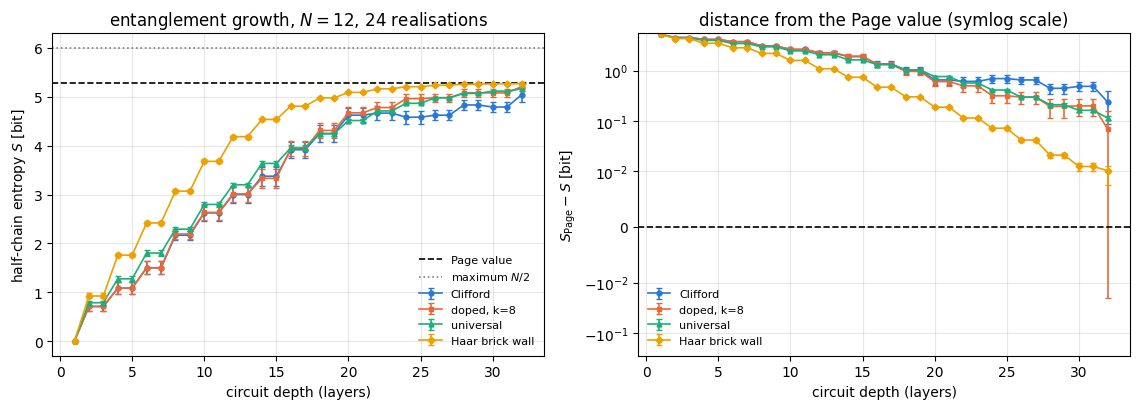

In [8]:
# ==============================================================================
# FIGURE 1: half-chain entanglement entropy versus circuit depth, four gate sets
# ==============================================================================
layers = np.arange(1, 2 * ND_ENT + 1)
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))
for i, (lab, (o, _)) in enumerate(ent.items()):
    m, e = o[:, :, 0].mean(axis=0), o[:, :, 0].std(axis=0) / np.sqrt(R_ENT)
    axes[0].errorbar(layers, m, yerr=e, color=PALETTE[i], marker=MARKERS[i], ms=3.5, lw=1.2, capsize=2, label=lab)
    axes[1].errorbar(layers, S_page - m, yerr=e, color=PALETTE[i], marker=MARKERS[i], ms=3.5, lw=1.2, capsize=2,
                     label=lab)
axes[0].axhline(S_page, color="k", ls="--", lw=1.2, label="Page value")
axes[0].axhline(N_ENT // 2, color="gray", ls=":", lw=1.2, label=r"maximum $N/2$")
axes[0].set_xlabel("circuit depth (layers)")
axes[0].set_ylabel(r"half-chain entropy $S$ [bit]")
axes[0].set_title(rf"entanglement growth, $N={N_ENT}$, {R_ENT} realisations")
axes[0].legend(fontsize=8, loc="lower right")
axes[1].axhline(0.0, color="k", ls="--", lw=1.2)
axes[1].set_yscale("symlog", linthresh=1e-2)
axes[1].set_xlabel("circuit depth (layers)")
axes[1].set_ylabel(r"$S_{\mathrm{Page}} - S$ [bit]")
axes[1].set_title("distance from the Page value (symlog scale)")
axes[1].legend(fontsize=8)
fig.tight_layout()
plt.show()

### 4.2 What the measurement says

The entropy grows roughly linearly at first and then bends over towards the Page value. Over the first $8$ layers the
average rate is $2.17/8=0.27$ bit per layer for the Clifford family, $0.29$ for the universal family and $0.38$ for
the Haar brick wall, below the bounds of $0.5$ and $1$ bit per layer derived above. The Haar brick wall is the
fastest: it reaches within $0.5$ bit of the Page value by depth $16$ and within $0.01$ bit by depth $32$. The three
CZ-based families are slower, because one CZ adds at most one bit across the cut, but by depth $32$ all four are
close to the Page value:

| family | $S$ at depth 32 [bit] | distance from Page (5.279 bit) |
|---|---|---|
| Clifford | $5.042\pm0.150$ | $0.24$ |
| doped, $k=8$ | $5.210\pm0.089$ | $0.07$ |
| universal | $5.165\pm0.009$ | $0.11$ |
| Haar brick wall | $5.269\pm0.003$ | $0.01$ |

**The four families differ by at most $0.23$ bit out of $5.28$, under $5\%$.** A Clifford circuit, which a laptop
simulates in $O(N)$ per Clifford gate, produces essentially as much half-chain entanglement as a Haar-random state, which no
classical method reproduces. Entanglement, by itself, does not separate easy from hard.

One detail of the figure is already a hint about *why*. The error bars of the Clifford and doped families are one to
two orders of magnitude larger than those of the two Haar families, and they stay large at saturation. The scatter has
a structural origin: the next section proves that the entanglement entropy of a stabilizer state is an **integer**
number of bits, so the Clifford ensemble scatters over the discrete values $4,5,6$, while the Haar ensemble
concentrates tightly around $5.27$. The structure of the entanglement is different even where its amount is the same.
The Clifford family has also not fully saturated at depth $32$: Exercise 2 continues it to larger depth.

The last column of the printed table is the rescaled collision probability $Z$. Its ensemble mean does *not* separate
the families: the Clifford value $1.75\pm0.14$ is $1.8$ standard errors from $2$, and Section 8 shows that the exact
average over random stabilizer states equals the Haar value $2D/(D+1)$. What differs is the distribution of $Z$ over
realisations, which Section 8 examines.

## 5. Diagnostic 2: magic

### 5.1 The stabilizer Renyi entropy in one page

[Notebook 27](27_stabilizer_renyi_entropy.ipynb) derives everything used here; this is the summary.

Expand $\lvert\psi\rangle\langle\psi\rvert$ in the $4^N$ Pauli strings $P$. Because the strings are orthogonal,
$\mathrm{Tr}(PQ)=2^N\delta_{PQ}$, the expansion coefficients are the expectation values $\langle P\rangle$, and for a
pure state the numbers

$$ \Xi_P=\frac{\langle\psi\vert P\vert\psi\rangle^2}{2^N},\qquad \sum_P\Xi_P=\mathrm{Tr}\,\rho^2=1 $$

form a probability distribution over Pauli strings (the *characteristic distribution*). The stabilizer Renyi entropy is
its Renyi entropy, shifted so that stabilizer states give zero:

$$ M_\alpha(\psi)=\frac{1}{1-\alpha}\log_2\sum_P\Xi_P^\alpha-N=\frac{1}{1-\alpha}\log_2\Big(\frac1{2^N}\sum_P\lvert\langle P\rangle\rvert^{2\alpha}\Big). $$

A stabilizer state has $\langle P\rangle\in\{0,\pm1\}$ with exactly $2^N$ non-zero values, so $\Xi$ is flat on $2^N$
strings and $M_\alpha=0$; conversely $M_\alpha=0$ forces the state to be a stabilizer state (Leone, Oliviero and Hamma
2022). $M_\alpha$ is additive over tensor products and invariant under Clifford unitaries — exactly the properties a
resource measure needs.

The brute-force sum over $4^N$ strings costs $O(8^N)$. The fast route writes $P=i^{a\cdot b}X^aZ^b$ with bit strings
$a,b$ and recognises the $b$-sum as a Walsh-Hadamard transform of $f_a[s]=\psi^*[s\oplus a]\,\psi[s]$, which brings the
cost down to $O(N4^N)$. We copy that implementation verbatim.

In [9]:
# ==============================================================================
# STEP 4: magic -- the Walsh-Hadamard algorithm for M_alpha  (copied from notebook 27, Section 9)
# ==============================================================================
# The four functions below are copied verbatim from notebook 27; the equation numbers in their docstrings
# (Eqs. 9, 17, 18) refer to that notebook.
def wht_all_axes(f):
    """Unnormalised Walsh-Hadamard transform over all N binary axes of the tensor f.

    MATH   F[b] = sum_s (-1)^(b.s) f[s],  b, s in {0,1}^N
    IMPLEMENTATION  (-1)^(b.s) factorises over qubits, and [[1,1],[1,-1]]_{b,s} = (-1)^(b s),
           so the transform is that 2x2 matrix applied to EVERY axis: N calls of `apply_gate`.
    COST   N einsums of O(2^N) each = O(N 2^N) time, O(2^N) memory, no temporary of size 4^N.
    JAX    pure and shape-static -> jit/vmap-able; works on a batched leading axis under vmap.
    """
    Hun = jnp.array([[1, 1], [1, -1]], dtype=f.dtype)
    for q in range(f.ndim):
        f = apply_gate(f, Hun, [q])
    return f


@partial(jax.jit, static_argnames=("N",))
def _pauli_moment_batch(flat, a_batch, two_alpha, N):
    """sum over the batch of X-patterns `a` of  sum_b |<P_{a,b}>|^(2 alpha).

    MATH   <P_{a,b}> = i^(a.b) * WHT_b[ f_a ],   f_a[s] = conj(psi[s XOR a]) psi[s]   (Eqs. 17, 18)
           |i^(a.b)| = 1, so the phase never enters |<P>|^(2 alpha).
    JAX    vmap over `a`; `flat[idx ^ a]` is a gather with a traced index (no Python `if`).
           `N` is static because it fixes the tensor shape (2,)*N and hence the einsum strings.
    COST   len(a_batch) * O(N 2^N) time, len(a_batch) * O(2^N) memory.
    """
    idx = jnp.arange(2 ** N)

    def for_a(a):
        f = (jnp.conj(flat[idx ^ a]) * flat).reshape((2,) * N)
        return jnp.sum(jnp.abs(wht_all_axes(f)) ** two_alpha)

    return jnp.sum(jax.vmap(for_a)(a_batch))


def sre(psi, alpha=2.0, batch=256):
    """Stabilizer Renyi entropy M_alpha of a PURE state (Eq. 9), Walsh-Hadamard algorithm.

    MATH   M_alpha = (1-alpha)^-1 log2( 2^-N sum_P |<P>|^(2 alpha) ),  sum over all 4^N Pauli strings.
    COST   O(N 4^N) time; memory O(batch * 2^N) on top of the state.
    """
    N = psi.ndim
    flat = psi.reshape(-1)
    batch = min(int(batch), 2 ** N)
    two_alpha = jnp.asarray(2.0 * alpha, dtype=RDTYPE)
    all_a = jnp.arange(2 ** N)
    total = jnp.zeros((), dtype=RDTYPE)
    for start in range(0, 2 ** N, batch):
        total = total + _pauli_moment_batch(flat, all_a[start:start + batch], two_alpha, N)
    return float(jnp.log2(total / 2 ** N) / (1.0 - alpha))


def sre_batch_of_states(psis, alpha=2.0, batch=64):
    """M_alpha for a STACK of states, shape (R,) + (2,)*N: vmap over states as well as over X-patterns.

    JAX    the inner vmap is over `a`, the outer over the R states; memory is R * batch * 2^N complex.
    """
    N = psis.ndim - 1
    flats = psis.reshape(psis.shape[0], -1)
    batch = min(int(batch), 2 ** N)
    two_alpha = jnp.asarray(2.0 * alpha, dtype=RDTYPE)
    all_a = jnp.arange(2 ** N)
    per_state = jax.vmap(_pauli_moment_batch, in_axes=(0, None, None, None))
    total = jnp.zeros((psis.shape[0],), dtype=RDTYPE)
    for start in range(0, 2 ** N, batch):
        total = total + per_state(flats, all_a[start:start + batch], two_alpha, N)
    return np.asarray(jnp.log2(total / 2 ** N) / (1.0 - alpha))


# CHECKPOINT 2a: known exact values (notebook 27) -- stabilizer states give 0, T|+> gives log2(4/3) per copy
t_plus_4 = product_state("++++")
for q in range(4):
    t_plus_4 = apply_gate(t_plus_4, T, [q])
print(f"M_2( (T|+>)^4 )  = {sre(t_plus_4):.12f}   exact 4 log2(4/3) = {4 * LOG2_4_3:.12f}")
print(f"M_2( GHZ_6 )     = {sre(ghz_state(6)):+.3e}   (stabilizer state: exactly 0)")
print(f"M_2( cluster_6 ) = {sre(cluster_state(6)):+.3e}   (stabilizer state: exactly 0)")
assert abs(sre(t_plus_4) - 4 * LOG2_4_3) < 1e-9 and abs(sre(ghz_state(6))) < 1e-9

M_2( (T|+>)^4 )  = 1.660149997115   exact 4 log2(4/3) = 1.660149997115
M_2( GHZ_6 )     = +1.281e-15   (stabilizer state: exactly 0)


M_2( cluster_6 ) = +5.125e-15   (stabilizer state: exactly 0)


### 5.2 Magic versus depth and gate set

The magic is too expensive to evaluate inside the scan ($O(N4^N)$ per state, against $O(N2^N)$ for a whole layer), so
we record the *state* after every double layer with `run_brickwall_1q_snapshots` and batch the magic computation
afterwards. The system size drops to $N=8$: $4^8=65\,536$ Pauli strings per state is affordable, $4^{12}$ is not.
The half-chain entropy is computed from the same snapshots, so the two resources are compared on identical states.

Two reference values, both derived in notebook 27:

$$ M_2^{\rm Haar}=\log_2\frac{2^N+3}{4},\qquad M_2^{\max}=\log_2\frac{2^N+1}{2} . $$

A third reference applies to the doped families. Leone, Oliviero and Hamma (2022) computed the average linear
stabilizer entropy $M_{\rm lin}=1-2^{-M_2}$ of a state $C_kKC_{k-1}\cdots KC_0\vert0\cdots0\rangle$ in which every $C_j$
is a uniformly random element of the full $N$-qubit Clifford group and every $K$ is a $T$ gate on one qubit. With
$d=2^N$ their result (Eq. (19) of notebook 27) reads

$$ \mathbb E\big[M_{\rm lin}\big]=1-\frac{4+(d-1)f^{k}}{d+3},\qquad f=\frac{6d^2-6d-8}{8(d^2-1)}\;\to\;\frac34 , $$

and $M_2^{\rm LOH}(k)=-\log_2\big(1-\mathbb E[M_{\rm lin}]\big)$ is a lower bound on the average $M_2$ of that ensemble
by Jensen's inequality. It interpolates between $k\log_2\frac43$ for small $k$ and the Haar value for $k\gg N$.
Notebook 27 confirms it numerically with a control circuit in which every $T$ gate is followed by its own block of
$3N$ Clifford layers.


In [10]:
# ==============================================================================
# STEP 5: magic M_2 and entanglement versus circuit depth for the four gate sets
# ==============================================================================
# ------------------------------- PARAMETERS ----------------------------------
N_MAG = 8                  # qubits (4^N = 65536 Pauli strings per state)
ND_MAG = 8                 # double layers -> depth 16
R_MAG = 12                 # realisations per family
# -----------------------------------------------------------------------------
keys_mag = jax.random.split(jax.random.PRNGKey(4242), R_MAG)
snap_1q = jax.jit(jax.vmap(lambda g: run_brickwall_1q_snapshots(zero_state(N_MAG), g)))
ent_of_snaps = jax.jit(jax.vmap(lambda p: entanglement_entropy(p, list(range(N_MAG // 2)))))
t0 = time.perf_counter()
mag, ent_mag = {}, {}


def magic_run(G):
    """Magic and half-chain entropy after every double layer, shape (R_MAG, ND_MAG) each."""
    _, snaps = snap_1q(G.reshape(R_MAG, ND_MAG, 2, N_MAG, 2, 2))
    flat_snaps = snaps.reshape((R_MAG * ND_MAG,) + (2,) * N_MAG)
    return (sre_batch_of_states(flat_snaps).reshape(R_MAG, ND_MAG),
            np.asarray(ent_of_snaps(flat_snaps)).reshape(R_MAG, ND_MAG))


for lab, k in (("Clifford", 0), ("doped, k=4", 4), ("doped, k=16", 16)):
    masks = t_masks(jax.random.PRNGKey(300 + k), R_MAG, 2 * ND_MAG, N_MAG, k)
    mag[lab], ent_mag[lab] = magic_run(jax.vmap(lambda a, m: clifford_gate_array(a, m, 2 * ND_MAG, N_MAG))(keys_mag, masks))
mag["universal"], ent_mag["universal"] = magic_run(jax.vmap(lambda a: haar_gate_array(a, 2 * ND_MAG, N_MAG))(keys_mag))

M2_haar = float(np.log2((2 ** N_MAG + 3) / 4))
M2_max = float(np.log2((2 ** N_MAG + 1) / 2))
S_page_mag = page_entropy_bits(2 ** (N_MAG // 2), 2 ** (N_MAG - N_MAG // 2))
haar_states_mag = jnp.stack([haar_state(k, N_MAG) for k in jax.random.split(jax.random.PRNGKey(5150), R_MAG)])
M2_haar_meas = sre_batch_of_states(haar_states_mag)
print(f"N = {N_MAG}, depth = {2 * ND_MAG}, {R_MAG} realisations per family  ({time.perf_counter() - t0:.1f} s)")
print(f"Haar reference log2((2^N+3)/4) = {M2_haar:.4f} bit   (measured on {R_MAG} exact Haar states: "
      f"{M2_haar_meas.mean():.4f} +- {M2_haar_meas.std() / np.sqrt(R_MAG):.4f} bit)")
print(f"maximum       log2((2^N+1)/2)  = {M2_max:.4f} bit;   Page value at N={N_MAG}: {S_page_mag:.4f} bit")
d_mag = 2 ** N_MAG
f_T = (6 * d_mag ** 2 - 6 * d_mag - 8) / (8 * (d_mag ** 2 - 1))          # f of the LOH law at theta = pi/4
M2_loh = {k: float(-np.log2((4 + (d_mag - 1) * f_T ** k) / (d_mag + 3))) for k in (4, 16)}
print(f"LOH law (T gates separated by global random Cliffords), annealed M_2: k=4 -> {M2_loh[4]:.4f} bit, "
      f"k=16 -> {M2_loh[16]:.4f} bit;  k log2(4/3): {4 * LOG2_4_3:.4f}, {16 * LOG2_4_3:.4f} bit\n")
print(f"{'depth':>6s}" + "".join(f"{lab + ': M_2':>21s}" for lab in mag))
for d in range(ND_MAG):
    print(f"{2 * (d + 1):6d}" + "".join(f"{v[:, d].mean():13.4f} +-{v[:, d].std() / np.sqrt(R_MAG):6.4f}"
                                        for v in mag.values()))
print(f"\n{'depth':>6s}" + "".join(f"{lab + ': S':>21s}" for lab in ent_mag))
for d in range(ND_MAG):
    print(f"{2 * (d + 1):6d}" + "".join(f"{v[:, d].mean():13.4f} +-{v[:, d].std() / np.sqrt(R_MAG):6.4f}"
                                        for v in ent_mag.values()))

# wrong control: the crowded brick wall (16 T gates in 16 layers) lies clearly BELOW the LOH lower bound at k=16
m16, e16 = mag["doped, k=16"][:, -1].mean(), mag["doped, k=16"][:, -1].std() / np.sqrt(R_MAG)
print(f"\nk=16 at depth 16: {m16:.3f} +- {e16:.3f} bit, i.e. {(M2_loh[16] - m16) / e16:.1f} standard errors below "
      f"the LOH value {M2_loh[16]:.3f} bit")
assert M2_loh[16] - m16 > 3 * e16

N = 8, depth = 16, 12 realisations per family  (4.3 s)
Haar reference log2((2^N+3)/4) = 6.0168 bit   (measured on 12 exact Haar states: 6.0193 +- 0.0024 bit)
maximum       log2((2^N+1)/2)  = 7.0056 bit;   Page value at N=8: 3.2819 bit
LOH law (T gates separated by global random Cliffords), annealed M_2: k=4 -> 1.6343 bit, k=16 -> 5.3386 bit;  k log2(4/3): 1.6601, 6.6406 bit

 depth        Clifford: M_2      doped, k=4: M_2     doped, k=16: M_2       universal: M_2
     2       0.0000 +-0.0000       0.2421 +-0.0591       0.5534 +-0.0893       3.1544 +-0.1258
     4       0.0000 +-0.0000       0.4496 +-0.0910       1.2210 +-0.1485       4.6097 +-0.0746
     6       0.0000 +-0.0000       0.6917 +-0.0893       1.5032 +-0.1931       5.0830 +-0.0692
     8       0.0000 +-0.0000       0.8647 +-0.1033       2.2110 +-0.2283       5.5558 +-0.0556
    10       0.0000 +-0.0000       1.0030 +-0.0910       2.7881 +-0.2457       5.7607 +-0.0413
    12       0.0000 +-0.0000       1.0722 +-0.0910      

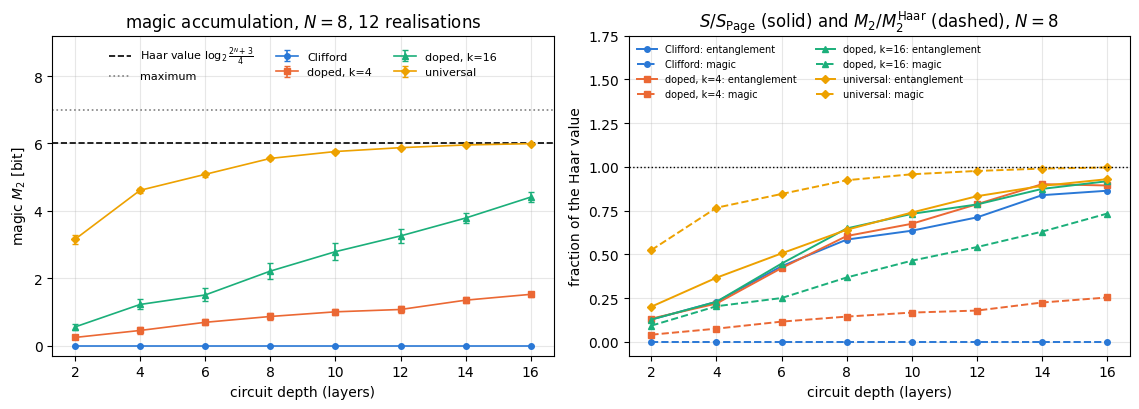

In [11]:
# ==============================================================================
# FIGURE 2: magic versus depth (left) and the two resources side by side (right)
# ==============================================================================
depths_mag = 2 * np.arange(1, ND_MAG + 1)
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))
for i, (lab, v) in enumerate(mag.items()):
    axes[0].errorbar(depths_mag, v.mean(axis=0), yerr=v.std(axis=0) / np.sqrt(R_MAG),
                     color=PALETTE[i], marker=MARKERS[i], ms=4, lw=1.2, capsize=2, label=lab)
axes[0].axhline(M2_haar, color="k", ls="--", lw=1.2, label=r"Haar value $\log_2\frac{2^N+3}{4}$")
axes[0].axhline(M2_max, color="gray", ls=":", lw=1.2, label="maximum")
axes[0].set_xlabel("circuit depth (layers)")
axes[0].set_ylabel(r"magic $M_2$ [bit]")
axes[0].set_title(rf"magic accumulation, $N={N_MAG}$, {R_MAG} realisations")
axes[0].set_ylim(-0.3, 9.2)                              # head-room for the legend above the curves
axes[0].legend(fontsize=8, loc="upper center", ncol=3)
for i, lab in enumerate(mag):
    axes[1].plot(depths_mag, ent_mag[lab].mean(axis=0) / S_page_mag, color=PALETTE[i], marker=MARKERS[i], ms=4, lw=1.4,
                 label=f"{lab}: entanglement")
    axes[1].plot(depths_mag, mag[lab].mean(axis=0) / M2_haar, color=PALETTE[i], marker=MARKERS[i], ms=4, lw=1.4,
                 ls="--", label=f"{lab}: magic")
axes[1].axhline(1.0, color="k", ls=":", lw=1)
axes[1].set_xlabel("circuit depth (layers)")
axes[1].set_ylabel("fraction of the Haar value")
axes[1].set_title(rf"$S/S_{{\mathrm{{Page}}}}$ (solid) and $M_2/M_2^{{\mathrm{{Haar}}}}$ (dashed), $N={N_MAG}$")
axes[1].legend(fontsize=7, ncol=2, loc="upper left")
axes[1].set_ylim(-0.08, 1.75)
fig.tight_layout()
plt.show()

In [12]:
# ==============================================================================
# STEP 5b / CHECKPOINT 2b: where does the magic of the FIRST double layer come from?
# ==============================================================================
# One double layer = [1q gates] [even CZ] [1q gates] [odd CZ].  We measure M_2 after each of the four half-steps.
# MATH  a pure qubit state with Bloch vector n has  M_2 = -log2( (1 + n_x^4 + n_y^4 + n_z^4) / 2 );
#       M_alpha is additive over tensor factors and invariant under Clifford unitaries (CZ is Clifford).
n_sphere = np.random.default_rng(0).normal(size=(200000, 3))
n_sphere /= np.linalg.norm(n_sphere, axis=1, keepdims=True)
m2_one_qubit = float(np.mean(-np.log2((1.0 + np.sum(n_sphere ** 4, axis=1)) / 2.0)))

stages = np.zeros((R_MAG, 4))
for r, kk in enumerate(jax.random.split(jax.random.PRNGKey(4242), R_MAG)):
    gk = jax.random.split(kk, 2 * N_MAG)
    psi = zero_state(N_MAG)
    for q in range(N_MAG):
        psi = apply_gate(psi, haar_unitary(gk[q], 2), [q])
    stages[r, 0] = sre(psi)                                                  # product of N Haar qubit states
    for q in range(0, N_MAG - 1, 2):
        psi = apply_gate(psi, CZ, [q, q + 1])
    stages[r, 1] = sre(psi)                                                  # + even-bond CZ (Clifford)
    for q in range(N_MAG):
        psi = apply_gate(psi, haar_unitary(gk[N_MAG + q], 2), [q])
    stages[r, 2] = sre(psi)                                                  # + second single-qubit layer
    for q in range(1, N_MAG - 1, 2):
        psi = apply_gate(psi, CZ, [q, q + 1])
    stages[r, 3] = sre(psi)                                                  # + odd-bond CZ  = "depth 2"

print(f"average magic of ONE Haar-random qubit: {m2_one_qubit:.4f} bit  ->  {N_MAG} independent qubits: "
      f"{N_MAG * m2_one_qubit:.4f} bit")
for i, lab in enumerate(["after single-qubit layer 1 (a product state)", "after the even-bond CZ layer",
                         "after single-qubit layer 2", "after the odd-bond CZ layer  (= depth 2)"]):
    print(f"  M_2 {lab:44s} = {stages[:, i].mean():.4f} +- {stages[:, i].std() / np.sqrt(R_MAG):.4f} bit")
print(f"\nCZ is Clifford, so it must not change M_2:  max |dM_2| over both CZ layers = "
      f"{max(np.max(np.abs(stages[:, 1] - stages[:, 0])), np.max(np.abs(stages[:, 3] - stages[:, 2]))):.2e}")
assert np.max(np.abs(stages[:, 1] - stages[:, 0])) < 1e-9
assert np.max(np.abs(stages[:, 3] - stages[:, 2])) < 1e-9
assert abs(stages[:, 0].mean() - N_MAG * m2_one_qubit) < 4 * stages[:, 0].std() / np.sqrt(R_MAG)

average magic of ONE Haar-random qubit: 0.3305 bit  ->  8 independent qubits: 2.6440 bit
  M_2 after single-qubit layer 1 (a product state) = 2.7488 +- 0.1339 bit
  M_2 after the even-bond CZ layer                 = 2.7488 +- 0.1339 bit
  M_2 after single-qubit layer 2                   = 3.1544 +- 0.1258 bit
  M_2 after the odd-bond CZ layer  (= depth 2)     = 3.1544 +- 0.1258 bit

CZ is Clifford, so it must not change M_2:  max |dM_2| over both CZ layers = 5.77e-15


### 5.3 What the measurement says

The magic separates what the entropy could not, and it does so on the first line of the table.

* **Clifford: $M_2=0.0000\pm0.0000$ at every depth**, for every realisation, to machine precision. Section 2.3
  explains it: a Clifford circuit maps $\lvert0\dots0\rangle$, a stabilizer state,
  to another stabilizer state, and $M_\alpha$ vanishes identically on that set. No amount of depth changes it.
* **Doped circuits accumulate magic gradually.** With $k=4$ $T$ gates spread over $16$ layers, $M_2$ climbs to
  $1.52\pm0.07$ bit, which is $3.7\times\log_2\frac43$, below both $4\log_2\frac43=1.66$ bit (four $T\vert+\rangle$
  states) and the LOH value $1.63$ bit. With $k=16$ it reaches $4.41\pm0.14$ bit. The count $16\log_2\frac43=6.64$
  bit is no reference there, since it exceeds the Haar value $6.02$ bit: magic saturates, and the LOH law, which
  includes saturation, gives $5.34$ bit at $k=16$. Most of the distance from $6.64$ bit is therefore saturation. The
  remaining $0.93$ bit, about seven standard errors (the assert above), is a property of this circuit: $16$ $T$ gates
  crowded into $16$ layers of nearest-neighbour gates, many of them acting before the Clifford layers have spread the
  state over the chain. A $T$ gate does nothing when the stabilizer group of the state contains $\pm Z_q$ on its
  qubit, which is much more likely after a few local layers than after a global random Clifford. In the first layer,
  for instance, the qubit is in one of the six single-qubit stabilizer states, and $T$ acts trivially on two of them,
  $\vert0\rangle$ and $\vert1\rangle$. Notebook 27 (Section 10.1) measures the same circuit against a control that
  follows the LOH law.
* **The universal circuit is saturated almost immediately.** Already at depth $2$, $M_2=3.15\pm0.13$ bit. The
  bookkeeping is worth doing, because it shows where magic comes from. Depth $2$ is one *double* layer: single-qubit
  gates, even-bond CZ, single-qubit gates, odd-bond CZ. After the first single-qubit layer the state is a product of
  $N$ Haar-random qubit states, and $M_2$ of a product is the sum of the factors; the average magic of one
  Haar-random qubit is
  $\mathbb E\big[-\log_2\frac{1+n_x^4+n_y^4+n_z^4}{2}\big]=0.330$ bit for $\mathbf n$ uniform on the Bloch sphere, so
  $8\times0.330=2.64$ bit, and Step 5b measures $2.75\pm0.13$ bit for that intermediate state. The CZ layer then
  changes $M_2$ by *exactly nothing* — CZ is Clifford and $M_\alpha$ is Clifford-invariant, which Step 5b asserts to
  $10^{-9}$. The rise from $2.75$ to $3.15$ bit is produced entirely by the *second* single-qubit layer of the same
  double layer, acting on a state that the first CZ layer has already entangled. By depth $16$ it is
  $5.994\pm0.007$ bit, i.e. $99.6\%$ of the Haar value
  $\log_2\frac{2^N+3}{4}=6.017$ bit, which the $12$ exact Haar states reproduce at $6.019\pm0.002$ bit.

The right-hand panel is the point of the section. **Magic is a local resource and is injected immediately;
entanglement is a non-local resource and needs depth.** At depth $4$ the universal family already holds $77\%$ of the
Haar magic while its entanglement is at $37\%$ of the Page value; the Clifford family climbs the entanglement axis at a
comparable rate with the magic pinned at zero. Two orthogonal resources, two different time scales, and one circuit
architecture.

(The entanglement at $N=8$ has not quite saturated at depth $16=2N$: all four families sit at $2.8$-$3.1$ bit against
the Page value $3.28$. The depth needed for saturation grows with $N$, which is why Section 4 used $32$ layers at
$N=12$.)

## 6. The entanglement spectrum

### 6.1 Definition

The entropy $S$ compresses the whole Schmidt decomposition into one number. The **entanglement spectrum** keeps all of
it. With $p_j=\lambda_j^2$ the eigenvalues of $\rho_A=\mathrm{Tr}_B\lvert\psi\rangle\langle\psi\rvert$, write

$$ \rho_A=e^{-H_E},\qquad \xi_j=-\ln p_j , $$

so that $H_E$ — the *entanglement Hamiltonian* — has "levels" $\xi_j\ge0$.
Two different properties of the numbers $\xi_j$ can be studied:

* their **density** (how many levels per unit $\xi$), a coarse, smooth property;
* their **correlations** on the scale of the mean level spacing, the fine, universal property that random-matrix
  theory describes and the subject of Section 7.

### 6.2 Theorem: the entanglement spectrum of a stabilizer state is exactly flat

**Claim.** Let $\lvert\psi\rangle$ be stabilized by the abelian group $\mathcal S=\langle g_1,\dots,g_N\rangle$ of
$2^N$ Pauli strings with $-\mathbb 1\notin\mathcal S$, and cut the qubits into $A$ ($n_A$ qubits) and $B$. Then
$\rho_A$ has $2^{n_A-a}$ non-zero eigenvalues, **all equal** to $2^{a-n_A}$, where $2^a=\lvert\mathcal S_A\rvert$ and
$\mathcal S_A=\{g\in\mathcal S:\ g \text{ acts as the identity on } B\}$. Consequently

$$ S_A=(n_A-a)\ \text{bits, an integer},\qquad \xi_j=(n_A-a)\ln2\ \text{for every } j . $$

**Proof.** A stabilizer state is the uniform projector onto the joint $+1$ eigenspace of its stabilizers,

$$ \lvert\psi\rangle\langle\psi\rvert=\prod_{i=1}^N\frac{\mathbb 1+g_i}{2}=\frac1{2^N}\sum_{g\in\mathcal S}g , $$

because expanding the product generates each of the $2^N$ group elements exactly once. Trace out $B$. Every $g$
factorises as $g=g_A\otimes g_B$ with $g_A,g_B$ Pauli strings, and $\mathrm{Tr}_B(g_A\otimes g_B)=g_A\,\mathrm{Tr}\,g_B$;
a Pauli string has zero trace unless it is the identity, and $\mathrm{Tr}\,\mathbb 1_B=2^{n_B}$. Only the elements of
$\mathcal S_A$ survive:

$$ \rho_A=\frac{2^{n_B}}{2^N}\sum_{g\in\mathcal S_A}g_A=\frac1{2^{n_A}}\sum_{g\in\mathcal S_A}g_A . $$

$\mathcal S_A$ is an abelian group of commuting Pauli strings on $n_A$ qubits that does not contain $-\mathbb 1$, so it
has $a$ independent generators $h_1,\dots,h_a$ and $2^a$ elements, and by the same expansion as above

$$ \Pi_A=\frac1{2^a}\sum_{g\in\mathcal S_A}g_A=\prod_{i=1}^a\frac{\mathbb 1+h_i}{2} $$

is an orthogonal projector. Its rank is $2^{n_A}/2^a$: each factor $(\mathbb 1+h_i)/2$ halves the dimension, because
$h_i$ is a Pauli string with eigenvalues $\pm1$ of equal multiplicity, and the $h_i$ commute. Therefore

$$ \rho_A=2^{a-n_A}\,\Pi_A , $$

a multiple of a projector: its non-zero eigenvalues are all equal to $2^{a-n_A}$ and there are
$\mathrm{rank}\,\Pi_A=2^{n_A-a}$ of them. (Consistency: $\mathrm{Tr}\rho_A=2^{a-n_A}2^{n_A-a}=1$.) $\square$

Three corollaries we can test directly:

1. all non-zero $p_j$ are equal, so $p_j\times(\text{Schmidt rank})=1$ exactly;
2. the Schmidt rank is a power of two and $S_A=\log_2(\text{rank})$ is an **integer** number of bits;
3. $S_A=S_2^{(A)}=S_\infty^{(A)}$: every Renyi entropy of the cut gives the same number, so no entropy of any order
   can distinguish a stabilizer state from another stabilizer state of the same rank.

> **Physics insight.** This is the sharpest form of the statement that entanglement and complexity differ. A random
> stabilizer state can carry almost $N/2$ bits across the cut — as much as a Haar-random state — yet its entanglement
> is *structureless*: one number, the rank, determines the entire spectrum. There is nothing else in it to be hard.

In [13]:
# ==============================================================================
# STEP 6: testing the flat-spectrum theorem on the Clifford circuits of Section 4
# ==============================================================================
spectra_of = jax.jit(jax.vmap(lambda p: schmidt_values(p, list(range(N_ENT // 2))) ** 2))
p_cliff = np.asarray(spectra_of(ent["Clifford"][1]))                 # (R_ENT, 2^{N/2})

print(f"Clifford brick wall, N = {N_ENT}, depth {2 * ND_ENT}, {R_ENT} realisations, half-chain cut\n")
print(f"{'#':>3s} {'Schmidt rank':>13s} {'log2 rank':>10s} {'S [bit]':>9s} {'max |p_j x rank - 1|':>21s}")
flat_err, ranks = [], []
for i in range(6):
    pj = np.sort(p_cliff[i])[::-1]
    nz = pj[pj > 1e-12]
    err = float(np.max(np.abs(nz * len(nz) - 1.0)))
    S_i = float(-np.sum(nz * np.log2(nz)))
    print(f"{i:3d} {len(nz):13d} {np.log2(len(nz)):10.6f} {S_i:9.6f} {err:21.2e}")
for i in range(R_ENT):
    pj = np.sort(p_cliff[i])[::-1]
    nz = pj[pj > 1e-12]
    flat_err.append(float(np.max(np.abs(nz * len(nz) - 1.0))))
    ranks.append(len(nz))
print(f"\nover all {R_ENT} realisations: worst |p_j x rank - 1| = {max(flat_err):.2e}")
print(f"Schmidt ranks found: {sorted(set(ranks))}  (all powers of two: {all(r & (r - 1) == 0 for r in ranks)})")
print(f"entropies found [bit]: {sorted({int(round(float(np.log2(r)))) for r in ranks})}  (all integers, as the theorem demands)")
assert max(flat_err) < 1e-9
assert all(r & (r - 1) == 0 for r in ranks)

# the same check for the doped and universal families, where it must FAIL
for lab in (f"doped, k={K_DOPE}", "universal"):
    pj = np.sort(np.asarray(spectra_of(ent[lab][1]))[0])[::-1]
    nz = pj[pj > 1e-12]
    print(f"\n{lab:>16s}: {len(nz):3d} non-zero eigenvalues, "
          f"largest/smallest = {nz[0] / nz[-1]:.3e}, max |p_j x rank - 1| = {np.max(np.abs(nz * len(nz) - 1)):.3f}")

Clifford brick wall, N = 12, depth 32, 24 realisations, half-chain cut

  #  Schmidt rank  log2 rank   S [bit]  max |p_j x rank - 1|
  0            64   6.000000  6.000000              9.90e-14
  1            64   6.000000  6.000000              9.73e-14
  2            16   4.000000  4.000000              9.90e-14
  3            16   4.000000  4.000000              9.57e-14
  4            32   5.000000  5.000000              9.78e-14
  5            64   6.000000  6.000000              9.77e-14

over all 24 realisations: worst |p_j x rank - 1| = 1.04e-13
Schmidt ranks found: [16, 32, 64]  (all powers of two: True)
entropies found [bit]: [4, 5, 6]  (all integers, as the theorem demands)

      doped, k=8:  64 non-zero eigenvalues, largest/smallest = 3.382e+01, max |p_j x rank - 1| = 1.296

       universal:  64 non-zero eigenvalues, largest/smallest = 1.818e+04, max |p_j x rank - 1| = 3.977


Every prediction of the theorem is met. The Schmidt ranks of the $24$ Clifford realisations are $16$, $32$ and $64$ —
powers of two, nothing else; the entropies are exactly $4$, $5$ and $6$ bits to every printed decimal; and the
flatness $p_j\times\text{rank}=1$ holds to $1.0\times10^{-13}$, which is the accumulated round-off of some $560$
gates. This is also the explanation of the large error bars of Section 4: the Clifford ensemble is a *discrete*
distribution over three values, $4$, $5$ and $6$ bits, whose mean happens to land near the Page value.

The same test applied to the other two families fails, as it must: the first doped and the first universal
realisation have all $64$ eigenvalues non-zero and a largest-to-smallest ratio of $34$ and $1.8\times10^4$
respectively (Section 6.4 shows that not every doped state has full rank: the doped family averages $56$ non-zero
levels). Their entanglement has
*internal structure*, and the rest of this notebook is about reading it.

### 6.3 Marchenko-Pastur: the entanglement spectrum of a random state

At the other extreme, take $\lvert\psi\rangle$ Haar-random. Reshaping its amplitudes into the $d_A\times d_B$ matrix
$M_{ab}=\psi[a,b]$ (with $d_A=2^{n_A}$, $d_B=2^{n_B}$), a Haar-random state is a complex Gaussian matrix $G$ divided by
its Frobenius norm, and $\rho_A=MM^\dagger=GG^\dagger/\lVert G\rVert_F^2$ with $\lVert G\rVert_F^2\approx d_Ad_B$. So

$$ \rho_A=\frac{1}{d_A}\,W,\qquad W=\frac{1}{d_B}GG^\dagger , $$

and $W$ is exactly a **Wishart matrix**: the sample covariance of $d_B$ independent $d_A$-dimensional Gaussian vectors.
The Marchenko-Pastur theorem (1967) gives the limiting density of its eigenvalues $x=d_A\,p$ for aspect ratio
$\gamma=d_A/d_B\le1$:

$$ \rho_{\rm MP}(x)=\frac{\sqrt{(x_+-x)(x-x_-)}}{2\pi\gamma x}\quad\text{on }[x_-,x_+],\qquad x_\pm=(1\pm\sqrt\gamma)^2 . \tag{3} $$

It is normalised and has mean $1$, as it must be: $\sum_jp_j=1$ means $\langle x\rangle=1$. For the symmetric half-chain
cut, $\gamma=1$, the support is $[0,4]$ and

$$ \rho_{\rm MP}(x)=\frac{1}{2\pi}\sqrt{\frac{4-x}{x}} , $$

which diverges (integrably) at $x\to0$: a random state has *many* very small Schmidt weights.

**Transformation to the entanglement spectrum.** With $\xi=-\ln p=\ln d_A-\ln x$ the change of variables gives
$\lvert dx/d\xi\rvert=x$, so

$$ \rho_\xi(\xi)=\rho_{\rm MP}(x)\,x\Big\vert_{x=d_Ae^{-\xi}},\qquad \xi\ \text{on } [\ln d_A-\ln x_+,\ \ln d_A-\ln x_-] . \tag{4} $$

For $\gamma=1$ this is $\rho_\xi=\sqrt{x(4-x)}/2\pi$: the divergence at $x\to0$ becomes an exponentially decaying
tail at large $\xi$, and the left edge $\xi_{\min}=\ln(d_A/4)$ is a square-root edge. Eq. (4) is the curve every
scrambling circuit is compared against.

In [14]:
# ==============================================================================
# STEP 7: the Marchenko-Pastur law and the measured entanglement spectra
# ==============================================================================
def mp_density_x(x, gamma):
    """Marchenko-Pastur density of the rescaled eigenvalue x = d_A * p, Eq. (3).  gamma = d_A/d_B <= 1."""
    x_minus, x_plus = (1 - np.sqrt(gamma)) ** 2, (1 + np.sqrt(gamma)) ** 2
    inside = (x > x_minus) & (x < x_plus)
    out = np.zeros_like(np.asarray(x, dtype=float))
    xs = np.asarray(x, dtype=float)[inside]
    out[inside] = np.sqrt((x_plus - xs) * (xs - x_minus)) / (2 * np.pi * gamma * xs)
    return out


def mp_density_xi(xi, n_A, n_B):
    """Marchenko-Pastur density of the entanglement energy xi = -ln p, Eq. (4)."""
    d_A, d_B = 2 ** min(n_A, n_B), 2 ** max(n_A, n_B)
    gamma = d_A / d_B
    x = 2 ** n_A * np.exp(-np.asarray(xi, dtype=float))
    return mp_density_x(x, gamma) * x


def mp_grid(gamma, n=40001):
    """Quadrature grid for the MP law: x = x_- + (x_+ - x_-) sin^2(theta), theta uniform on [0, pi/2].

    WHY  rho_MP has square-root edges (and for gamma = 1 an integrable 1/sqrt(x) divergence at x = 0), so a
         uniform x-grid converges very slowly. The substitution absorbs the square root: the weight
         |dx/dtheta| = (x_+ - x_-) sin(2 theta) vanishes exactly where the density blows up.
    RETURNS  (x, weight, theta) with integral f = trapezoid(f(x) * weight, theta).
    """
    x_minus, x_plus = (1 - np.sqrt(gamma)) ** 2, (1 + np.sqrt(gamma)) ** 2
    th = np.linspace(0.0, np.pi / 2, n)
    return x_minus + (x_plus - x_minus) * np.sin(th) ** 2, (x_plus - x_minus) * np.sin(2 * th), th


# CHECKPOINT 3: the MP density must be normalised and have mean 1 (= Tr rho_A = 1)
for gamma in (1.0, 0.25):
    xq, wq, thq = mp_grid(gamma)
    dens = mp_density_x(xq, gamma) * wq
    norm_mp = np.trapezoid(dens, thq)
    mean_mp = np.trapezoid(xq * dens, thq)
    print(f"gamma = {gamma:4.2f}:  integral of rho_MP = {norm_mp:.6f} (exact 1), mean = {mean_mp:.6f} (exact 1)")
    assert abs(norm_mp - 1) < 2e-3 and abs(mean_mp - 1) < 2e-3

nA_sp, nB_sp = N_ENT // 2, N_ENT - N_ENT // 2
haar_exact = jnp.stack([haar_state(k, N_ENT) for k in jax.random.split(jax.random.PRNGKey(808), R_ENT)])
p_sets = {"Clifford": p_cliff,
          f"doped, k={K_DOPE}": np.asarray(spectra_of(ent[f"doped, k={K_DOPE}"][1])),
          "universal": np.asarray(spectra_of(ent["universal"][1])),
          "Haar brick wall": np.asarray(spectra_of(ent["Haar brick wall"][1])),
          "exact Haar states": np.asarray(spectra_of(haar_exact))}
xq, wq, thq = mp_grid(1.0, 4001)                       # gamma = 1: the symmetric half-chain cut
dens_q = mp_density_x(xq, 1.0) * wq
cdf_mp = np.concatenate([[0.0], np.cumsum(0.5 * (dens_q[1:] + dens_q[:-1]) * np.diff(thq))])
cdf_mp /= cdf_mp[-1]
ks_dist = {}
print(f"\n{'family':>18s} {'<#non-zero>':>12s} {'<x_max>':>9s} {'<x_min>':>10s} {'Kolmogorov distance to MP':>27s}")
for lab, pp in p_sets.items():
    x_all = np.sort((pp * 2 ** nA_sp).ravel())
    emp = np.searchsorted(x_all, xq, side="right") / len(x_all)
    ks_dist[lab] = float(np.max(np.abs(emp - cdf_mp)))
    nz_per = np.mean([np.sum(row > 1e-12) for row in pp])
    print(f"{lab:>18s} {nz_per:12.1f} {np.mean([np.max(r) * 2 ** nA_sp for r in pp]):9.3f} "
          f"{np.mean([np.min(r[r > 1e-12]) * 2 ** nA_sp for r in pp]):10.2e} {ks_dist[lab]:27.4f}")

gamma = 1.00:  integral of rho_MP = 0.999975 (exact 1), mean = 1.000000 (exact 1)
gamma = 0.25:  integral of rho_MP = 1.000000 (exact 1), mean = 1.000000 (exact 1)



            family  <#non-zero>   <x_max>    <x_min>   Kolmogorov distance to MP
          Clifford         37.3     2.208   2.21e+00                      0.4164
        doped, k=8         56.0     2.735   2.83e-01                      0.1247
         universal         64.0     4.500   1.77e-04                      0.0406
   Haar brick wall         64.0     3.777   2.67e-04                      0.0084
 exact Haar states         64.0     3.745   2.59e-04                      0.0066


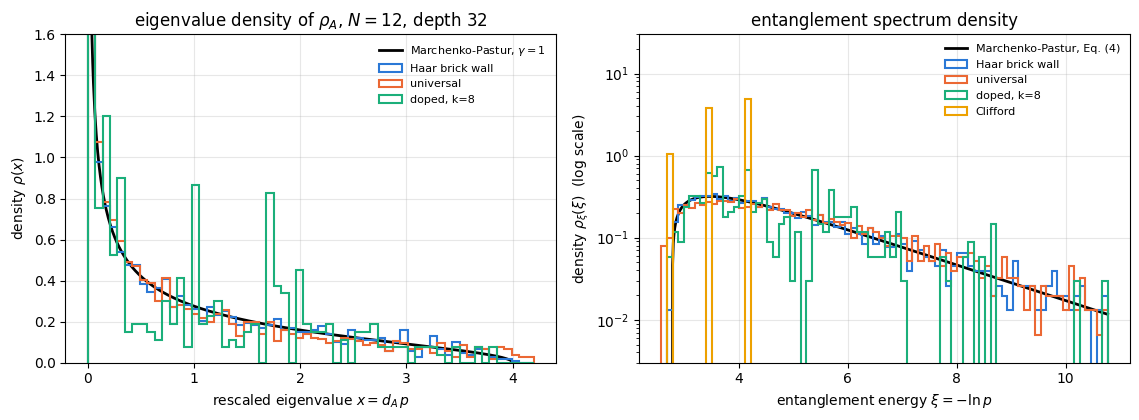

In [15]:
# ==============================================================================
# FIGURE 3: measured entanglement spectra against the Marchenko-Pastur law
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.3))
xg_plot = np.linspace(1e-4, 4.0, 600)
axes[0].plot(xg_plot, mp_density_x(xg_plot, 1.0), "k-", lw=2, label=r"Marchenko-Pastur, $\gamma=1$")
for i, lab in enumerate(["Haar brick wall", "universal", f"doped, k={K_DOPE}"]):
    x_all = (p_sets[lab] * 2 ** nA_sp).ravel()
    axes[0].hist(x_all, bins=60, range=(0, 4.2), density=True, histtype="step", lw=1.5, color=PALETTE[i], label=lab)
axes[0].set_xlabel(r"rescaled eigenvalue $x = d_A\,p$")
axes[0].set_ylabel(r"density $\rho(x)$")
axes[0].set_ylim(0, 1.6)
axes[0].set_title(rf"eigenvalue density of $\rho_A$, $N={N_ENT}$, depth {2 * ND_ENT}")
axes[0].legend(fontsize=8)

xi_grid = np.linspace(np.log(2 ** nA_sp / 4) - 0.2, np.log(2 ** nA_sp / 4) + 8.0, 600)
axes[1].plot(xi_grid, mp_density_xi(xi_grid, nA_sp, nB_sp), "k-", lw=2, label="Marchenko-Pastur, Eq. (4)")
for i, lab in enumerate(["Haar brick wall", "universal", f"doped, k={K_DOPE}", "Clifford"]):
    xi_all = -np.log(np.clip((p_sets[lab]).ravel(), 1e-300, None))
    xi_all = xi_all[np.isfinite(xi_all) & (xi_all < 30)]
    axes[1].hist(xi_all, bins=80, range=(xi_grid[0], xi_grid[-1]), density=True, histtype="step", lw=1.5,
                 color=PALETTE[i], label=lab)
axes[1].set_yscale("log")
axes[1].set_ylim(3e-3, 3e1)
axes[1].set_xlabel(r"entanglement energy $\xi = -\ln p$")
axes[1].set_ylabel(r"density $\rho_\xi(\xi)$  (log scale)")
axes[1].set_title("entanglement spectrum density")
axes[1].legend(fontsize=8, loc="upper right")
fig.tight_layout()
plt.show()

### 6.4 What the measurement says

The quadrature checkpoint confirms the two exact properties of Eq. (3), $\int\rho_{\rm MP}=1$ and
$\langle x\rangle=1$, to better than $3\times10^{-5}$, so the black curve is trustworthy. (The substitution
$x=x_-+(x_+-x_-)\sin^2\theta$ is what makes it so: on a uniform $x$-grid the $\gamma=1$ integral is wrong in the third
decimal, because the density diverges as $x^{-1/2}$ at the origin.)

The Kolmogorov distance between the measured eigenvalue distribution and the MP law orders the families exactly as the
other diagnostics do:

| family | non-zero levels (of 64) | $x_{\max}$ | $x_{\min}$ | distance to MP |
|---|---|---|---|---|
| Clifford | 37.3 | 2.208 | 2.208 | 0.416 |
| doped, $k=8$ | 56.0 | 2.74 | 0.283 | 0.125 |
| universal | 64.0 | 4.50 | $1.8\times10^{-4}$ | 0.041 |
| Haar brick wall | 64.0 | 3.78 | $2.7\times10^{-4}$ | 0.0084 |
| exact Haar states | 64.0 | 3.75 | $2.6\times10^{-4}$ | 0.0066 |

The Clifford row is the flat-spectrum theorem in the language of this section: $x_{\max}=x_{\min}=2.208$, one single
value, which is the average of $64/\mathrm{rank}\in\{1,2,4\}$ over the ensemble. In the right-hand panel it appears as
three sharp spikes at $\xi=4\ln2,5\ln2,6\ln2$ and nothing in between, up to an order of magnitude above the
smooth MP curve (the panel has a logarithmic vertical axis for that reason). The Haar brick wall reproduces MP to
within the statistical resolution of $24\times64$ levels — its distance
$0.0084$ is barely above the $0.0066$ that $24$ *exact* Haar states give — and the universal circuit is close but not
yet converged at depth $32$. The sharpest sign of that is $x_{\max}$: the MP edge is at $x_+=4$, but a finite
$64\times64$ matrix does not reach it, and the exact Haar states give $\langle x_{\max}\rangle=3.75$ (the Haar
brick wall, $3.78$). The universal circuit returns $4.50$ — above the edge and $20\%$ above the correct finite-size
value — so the excess is a finite-*depth* effect, an eigenvalue that the circuit has not yet pushed down; finite size
would move $x_{\max}$ the other way.
The doped family at $k=8$ sits in between, which is what "partially scrambled" looks like.

> **Physics insight.** The density $\rho_\xi$ is a *coarse* diagnostic: it distinguishes a flat spectrum from a spread
> one, and it says how far a circuit is from Haar. It cannot see the difference between a spread spectrum whose levels
> are independent and one whose levels repel. That distinction is the subject of the next section, and it is the one
> that turns out to be the sharpest.

## 7. Diagnostic 3: level statistics of the entanglement spectrum

### 7.1 The adjacent-gap ratio, and its two reference values

The density $\rho_\xi$ of the previous section is a smooth, non-universal object: it depends on $n_A$, on $n_B$, on the
state. The *correlations between neighbouring levels* are different — random-matrix theory predicts them to be
universal. Sort the entanglement energies $\xi_1\le\xi_2\le\dots\le\xi_n$, form the gaps $\delta_j=\xi_{j+1}-\xi_j$,
and define the **adjacent-gap ratio** (Oganesyan and Huse 2007)

$$ \tilde r_j=\frac{\min(\delta_j,\delta_{j+1})}{\max(\delta_j,\delta_{j+1})}\in[0,1],\qquad \langle\tilde r\rangle=\text{average over }j\text{ within one spectrum, then over realisations}. $$

The two averages are taken in that order throughout, and every error bar quoted below is the standard error of the
second one, i.e. it measures circuit-to-circuit scatter and not the scatter of individual gaps.

The ratio is used instead of the raw spacings because it needs **no unfolding**: multiplying all gaps in a local window
by the same factor (which is what a slowly varying density does) leaves $\tilde r$ unchanged, so the smooth part of
$\rho_\xi$ drops out and only the correlations survive.

**Uncorrelated (Poisson) levels.** If the gaps are independent and exponentially distributed, $\delta\sim\mathrm{Exp}(1)$,
put $t=\delta_1/\delta_2$. Its density is $f(t)=\int_0^\infty s\,e^{-ts}e^{-s}ds=(1+t)^{-2}$, hence

$$ \Pr[\tilde r\le x]=\Pr[t\le x]+\Pr[t\ge1/x]=\frac{x}{1+x}+\Big(1-\frac{1/x}{1+1/x}\Big)=\frac{2x}{1+x}, $$

so $\tilde r$ has density $2/(1+x)^2$ on $[0,1]$ and

$$ \langle\tilde r\rangle_{\rm Poisson}=\int_0^1\frac{2x}{(1+x)^2}dx=2\Big[\ln(1+x)+\frac1{1+x}\Big]_0^1=2\ln2-1=0.386294\ldots $$

**Correlated (Wigner-Dyson) levels.** If the levels repel, small gaps are suppressed, consecutive gaps become similar
and $\langle\tilde r\rangle$ rises. Atas, Bogomolny, Giraud and Roux (2013) give two sets of numbers for the Gaussian
ensembles, and they must not be mixed: the **$3\times3$ surmise** evaluates to $4-2\sqrt3=0.5359$ (GOE, $\beta=1$),
$2\sqrt3/\pi-\tfrac12=0.6027$ (GUE, $\beta=2$) and $0.6762$ (GSE, $\beta=4$), while their fits to **large** random
matrices give $0.5307$, $0.5996$ and $0.6744$. The differences, $2$-$4\times10^{-3}$, are of the same size as the
statistical errors below. We quote the large-$N$ GUE value $\langle\tilde r\rangle=0.5996$ throughout.

The appropriate reference ensemble follows from Section 6.3: $\rho_A$ of a Haar-random state is a complex Wishart
matrix (Section 6.3), i.e. it belongs to the Laguerre *unitary* ensemble: its eigenvalue repulsion in the bulk is
$\beta=2$, the same as GUE. So the value to expect for a maximally scrambled state is the **GUE** one, and a
Haar-random state with *real* amplitudes would give the GOE one instead.

**Degenerate levels.** If many levels are *degenerate*, all the gaps between them vanish, every $\tilde r_j$ is $0/0$
or $0/\delta$, and $\langle\tilde r\rangle\to0$. This is the extreme of level *attraction*, far below Poisson, and it
is exactly what the flat spectrum of a stabilizer state produces.

An exact degeneracy signals a *symmetry*, and random-matrix theory makes no statement about it: the textbook
prescription is to resolve the symmetry first — to keep one level per degenerate multiplet — and to look at
the correlations of what is left. We will do the measurement both ways, because the difference between the two turns
out to be the whole story of Section 7.3.

Level statistics of the entanglement spectrum were proposed as a measure of **entanglement complexity** by Chamon,
Hamma and Mucciolo (2014) and by Shaffer, Chamon, Hamma and Mucciolo (2014). Their physical statement is about
*reversibility*. Both papers entangle a random product state with a random circuit and then try to disentangle it back
to a product state by a **stochastic search**: a single gate is drawn at random from the same gate set the circuit was
built from, and accepted with probability $\min\{1,e^{-\kappa\Delta S}\}$, where $S$ is the *sum* of the entanglement
entropies over all $N-1$ contiguous cuts and $\kappa>0$ controls how often a gate that *raises* $S$ is accepted
(Chamon et al. minimise the Renyi-0 entropy $S_0=\log_2(\text{rank})$ and increase $\kappa$ during the search;
Shaffer et al. use a fixed $\kappa=5$). The searches succeed for some gate sets and fail for others,
and the failure coincides with the appearance of Wigner-Dyson statistics in the entanglement spectrum. The two papers
differ in what they test, and the distinction matters:

| paper | gate sets | entanglement level statistics | statistic used |
|---|---|---|---|
| Chamon, Hamma, Mucciolo (2014) | permutation gates: $\{$SWAP, CNOT$\}$ vs $\{$SWAP, CNOT, Toffoli$\}$ | semi-Poisson vs GOE | unfolded $P(s)$ and $\Delta_3(L)$ |
| Shaffer et al. (2014) | Clifford $\{$CNOT, $H$, $S\}$ vs universal $\{$CNOT, $H$, $T\}$ | Poisson vs GUE | $P(r)$, $r=\delta_{j+1}/\delta_j$, no unfolding |

The Clifford-versus-universal comparison that this section reproduces is therefore the one of **Shaffer et al.**,
whose abstract states that irreversibility "corresponds to Wigner-Dyson statistics in the level spacing of the
entanglement eigenvalues, and that this is obtained from a quantum circuit made from a set of universal gates for
quantum computation". (Chamon et al. work inside the permutation subgroup; their $\{$SWAP, CNOT, Toffoli$\}$ set is
universal for *classical* reversible computation, not for quantum computation, and they say so explicitly. Their
reversible set gives semi-Poisson rather than Poisson, and their irreversible set gives GOE rather than GUE, because
they keep the wave function real.) Zhou, Yang, Hamma and Chamon (2020) then asked how little non-Cliffordness is
needed and concluded, from a finite-size scaling analysis at $N=10$-$20$, that "in the thermodynamic limit, inserting
a single $T$ ($\pi/8$) gate in the middle of a random Clifford circuit is sufficient to alter the entanglement
spectrum from a Poisson to a Wigner-Dyson distribution". Their scaling variable is the **product** $kN$ of the number
of $T$ gates and the system size: since $\langle\tilde r\rangle$ is a function of $kN$ alone, any fixed $k\ge1$ ends
up at the Wigner-Dyson value as $N\to\infty$. We reproduce the diagnostic below and report what it gives at the sizes
this notebook can afford.

In [16]:
# ==============================================================================
# STEP 8: the adjacent-gap ratio of a spectrum, and an uncorrelated surrogate to calibrate it
# ==============================================================================
def entanglement_levels(p, tol=1e-12, dtol=1e-9):
    """Sorted entanglement energies xi = -ln p of one state, plus the tolerance below which a gap is a TIE.

    Eigenvalues below `tol` are numerical zeros and are dropped: an SVD returns 2^{n_A} singular values whatever
    the rank, and a padding zero would appear as a spurious level at xi ~ 39.  `eps` is scaled with the width of
    the spectrum, so "degenerate" means "closer than 1e-9 of the total spread", not "closer than 1e-9".
    """
    pj = np.sort(np.asarray(p))[::-1]
    pj = pj[pj > tol]
    xi = np.sort(-np.log(pj))
    eps = dtol * max(1.0, float(xi[-1] - xi[0])) if len(xi) else 0.0
    return xi, eps


def degenerate_fraction(p):
    """Fraction of entanglement levels that share their value with at least one other level (an exact tie)."""
    xi, eps = entanglement_levels(p)
    if len(xi) < 2:
        return np.nan
    tie = np.diff(xi) <= eps
    return float(np.mean(np.concatenate([tie, [False]]) | np.concatenate([[False], tie])))


def gap_ratio(p, keep=0.8, desymmetrise=False):
    """Mean adjacent-gap ratio <r> of the entanglement spectrum xi = -ln p of ONE state.

    MATH   xi sorted; delta_j = xi_{j+1} - xi_j;  r_j = min(delta_j, delta_{j+1}) / max(delta_j, delta_{j+1}).
    IMPLEMENTATION  only the central fraction `keep` of the levels is used, because the two spectral edges are not
           in the RMT bulk.  Gaps below the tie tolerance of `entanglement_levels` are set to EXACTLY zero before
           the ratio is formed, so a degenerate pair contributes r = 0 and a pair of ties contributes 0/0 -> 0.
           Without that step the ratio of two round-off gaps (both ~1e-16) is a uniform random number, and a flat
           stabilizer spectrum would report a spurious <r> ~ 0.01 instead of 0.
    `desymmetrise=True` keeps ONE representative of each degenerate multiplet before forming the gaps -- the
           standard random-matrix prescription of resolving a symmetry before looking at level correlations.
    RETURNS  float, or nan if fewer than 8 levels survive.
    """
    xi, eps = entanglement_levels(p)
    if len(xi) < 8:
        return np.nan
    if desymmetrise:
        xi = xi[np.concatenate([[True], np.diff(xi) > eps])]
    lo = int(len(xi) * (1 - keep) / 2)
    d = np.diff(xi[lo:len(xi) - lo])
    if len(d) < 3:
        return np.nan
    d = np.where(d <= eps, 0.0, d)
    hi = np.maximum(d[:-1], d[1:])
    return float(np.mean(np.where(hi > 0.0, np.minimum(d[:-1], d[1:]) / np.where(hi > 0.0, hi, 1.0), 0.0)))


def gap_ratio_ensemble(p_batch, keep=0.8, desymmetrise=False):
    """(mean, standard error) of <r> over the realisations in p_batch (shape (R, 2^{n_A})).
    The ratio is averaged over the gaps of EACH spectrum first, then over realisations; the quoted error is the
    standard error of that second average, i.e. it measures circuit-to-circuit scatter.
    Returns (nan, nan) if no realisation has enough levels (e.g. a product state: rank 1)."""
    v = np.array([gap_ratio(row, keep, desymmetrise) for row in np.asarray(p_batch)])
    v = v[np.isfinite(v)]
    if v.size == 0:
        return float("nan"), float("nan")
    return float(v.mean()), float(v.std() / np.sqrt(v.size))


def uncorrelated_surrogate(p_batch, rng, tol=1e-12):
    """Levels with the SAME density but no correlations: for each realisation draw as many levels as it has,
    independently, from the empirical distribution of all levels pooled over the ensemble.

    WHY  the gap ratio is only approximately density-independent on a finite spectrum. Running the identical
         estimator on a deliberately uncorrelated data set with the same density measures that residual bias:
         the surrogate MUST come out at the Poisson value 2 ln 2 - 1 if the estimator is unbiased.
    """
    xis = [np.sort(-np.log(np.sort(np.asarray(r))[::-1][np.sort(np.asarray(r))[::-1] > tol])) for r in p_batch]
    pool = np.sort(np.concatenate(xis))
    q = (np.arange(len(pool)) + 0.5) / len(pool)
    out = []
    for xi in xis:
        draws = np.sort(np.interp(rng.random(len(xi)), q, pool))
        lo = int(len(draws) * 0.1)
        d = np.diff(draws[lo:len(draws) - lo])
        out.append(np.mean(np.minimum(d[:-1], d[1:]) / np.maximum(np.maximum(d[:-1], d[1:]), 1e-300)))
    return float(np.mean(out)), float(np.std(out) / np.sqrt(len(out)))


# CHECKPOINT 4: the estimator must return GUE on Haar states and Poisson on the uncorrelated surrogate
rng_sur = np.random.default_rng(20260)
print(f"{'data set':>26s} {'<r> measured':>18s} {'reference':>22s}")
for lab in ("exact Haar states", "Haar brick wall"):
    m, e = gap_ratio_ensemble(p_sets[lab])
    print(f"{lab:>26s} {m:11.4f} +-{e:5.4f} {'GUE ' + str(R_GUE):>22s}")
m, e = uncorrelated_surrogate(p_sets["exact Haar states"], rng_sur)
print(f"{'uncorrelated surrogate':>26s} {m:11.4f} +-{e:5.4f} {'Poisson ' + f'{R_POISSON:.4f}':>22s}")
m_sur_haar = m
assert abs(gap_ratio_ensemble(p_sets["exact Haar states"])[0] - R_GUE) < 0.03
assert abs(m_sur_haar - R_POISSON) < 0.05          # 1.8 standard errors low here; see the discussion below

                  data set       <r> measured              reference
         exact Haar states      0.6076 +-0.0077             GUE 0.5996
           Haar brick wall      0.5908 +-0.0089             GUE 0.5996
    uncorrelated surrogate      0.3687 +-0.0098         Poisson 0.3863


The estimator passes both calibrations. On exact Haar-random states it returns $0.608\pm0.008$, the GUE value to
within its statistical error. On a deliberately uncorrelated data set *with the same level density* it returns
$0.369\pm0.010$, $1.8$ standard errors below $2\ln2-1=0.386$. Step 9 repeats the construction on independent Haar
states at $N=8,10,12$ and obtains $0.392$, $0.393$ and $0.401$, all within $1.6$ standard errors of the Poisson value
and on the other side of it, so at this precision the surrogate shows no bias for the Haar density. The surrogate
still has to be measured rather than assumed: for a more structured density the residual bias of the estimator on a
finite spectrum need not be small, and Step 9 finds such a case. The surrogate is the zero of the scale against which
every number below is read.

> **Common pitfall.** Two traps hide inside `gap_ratio`. First, an SVD returns $2^{n_A}$ singular values whatever the
> rank, so a low-rank spectrum comes padded with numerical zeros of size $10^{-17}$; left in, they turn into a handful
> of spurious "levels" at $\xi\approx39$ and wreck the statistic — hence the `tol` cut. Second, on a degenerate
> spectrum every gap *should* vanish, but in floating point it is $10^{-16}$ rather than $0$, and the ratio of two
> such numbers is a uniformly distributed random number, not $0$: a perfectly flat stabilizer spectrum would then
> report $\langle\tilde r\rangle\approx0.01$ — a meaningless number built entirely out of round-off. `gap_ratio`
> therefore rounds every gap below $10^{-9}$ of the spectral width down to exactly zero *before* forming the ratio,
> so a degenerate pair contributes $\tilde r=0$ and a pair of ties contributes $0/0\to0$. That is the physically right
> answer (maximal level attraction, the opposite of repulsion), but only because the convention was chosen
> deliberately. A number produced by a $0/0$ is never self-explanatory: say which convention produced it.

### 7.2 The seed state

Section 6.2 proved that a Clifford circuit applied to $\lvert0\dots0\rangle$ produces a stabilizer state whose
entanglement spectrum is a *single* level with multiplicity $2^S$. There are no gaps to speak of: every
$\delta_j$ is zero, $\langle\tilde r\rangle=0$ identically, and the comparison with Poisson or Wigner-Dyson is empty.

The way out is the one used in the literature on entanglement complexity: seed the circuit with a **generic product
state**, which carries no entanglement but is not a stabilizer state, and let the gate set decide what structure the
entanglement acquires. Chamon et al. (2014), Shaffer et al. (2014) and Zhou et al. (2020) all use the same seed, with
real amplitudes, and so do we:

$$ \lvert\psi(0)\rangle=\bigotimes_{q=1}^{N}\big(\cos\theta_q\lvert0\rangle+\sin\theta_q\lvert1\rangle\big),\qquad \theta_q\ \text{uniform in }[0,\pi), \tag{7} $$

and then apply the same brick-wall circuits as before, with $k$ $T$ gates inserted at random slots.

The choice of seed affects the result, and Section 7.3 comes back to it. Every Bloch vector of Eq. (7) lies in the
$xz$ plane, $\langle Y_q\rangle=0$. After a pure Clifford circuit, about half of the levels of the output spectrum
come in exactly degenerate *pairs*, never in larger multiplets, which points to an exact two-fold symmetry inherited
from the coplanarity; we demonstrate it numerically and do not derive it. Drawing the seed qubits from the full Bloch
sphere instead removes every degeneracy. Both choices are "generic product states"; they give different level
statistics, and the literature uses the coplanar one.

In [17]:
# ==============================================================================
# STEP 9: level statistics versus the number of T gates, for three system sizes
# ==============================================================================
def random_real_product_state(key, N):
    """(x)_q [ cos(theta_q)|0> + sin(theta_q)|1> ] with theta_q uniform in [0, pi).

    MATH   Ry(2 theta)|0> = cos(theta)|0> + sin(theta)|1>; the state has zero entanglement but is generically
           NOT a stabilizer state, so a Clifford circuit acting on it produces a non-degenerate spectrum.
    """
    th = jax.random.uniform(key, (N,), minval=0.0, maxval=jnp.pi)
    psi = zero_state(N)
    for q in range(N):
        psi = apply_gate(psi, ry(2 * th[q]), [q])
    return psi


def random_sphere_product_state(key, N):
    """Control seed: one Haar-random qubit state per site, i.e. Bloch vectors uniform on the WHOLE sphere.
    Same amount of entanglement (none) and the same genericity, but no <Y_q> = 0 constraint."""
    psi = zero_state(N)
    for q, kk in enumerate(jax.random.split(key, N)):
        psi = apply_gate(psi, haar_unitary(kk, 2), [q])
    return psi


# ------------------------------- PARAMETERS ----------------------------------
N_LEV = (8, 10, 12)              # system sizes
R_LEV = 24                       # circuit realisations per point
K_LEV = (0, 1, 2, 4, 8, 16, 32)  # numbers of T gates
DEPTH_FACTOR = 4                 # circuit depth = DEPTH_FACTOR * N layers (deep enough to saturate S)
# -----------------------------------------------------------------------------
t0 = time.perf_counter()
lev = {}
for N in N_LEV:
    n_double = DEPTH_FACTOR * N // 2
    keys = jax.random.split(jax.random.PRNGKey(31337), R_LEV)
    seed_keys = jax.random.split(jax.random.PRNGKey(2718), R_LEV)
    psi0 = jnp.stack([random_real_product_state(k, N) for k in seed_keys])
    psi0_sph = jnp.stack([random_sphere_product_state(k, N) for k in seed_keys])
    runner = jax.jit(jax.vmap(lambda g, p: run_brickwall_1q(p, g, half_chain_diagnostics)))
    spec_N = jax.jit(jax.vmap(lambda p: schmidt_values(p, list(range(N // 2))) ** 2))
    row, p_cliff_N = [], None
    for k in K_LEV:
        masks = t_masks(jax.random.PRNGKey(900 + k), R_LEV, 2 * n_double, N, k)
        G = jax.vmap(lambda a, m: clifford_gate_array(a, m, 2 * n_double, N))(keys, masks)
        psi_f, obs = runner(G.reshape(R_LEV, n_double, 2, N, 2, 2), psi0)
        pk = np.asarray(spec_N(psi_f))
        if k == 0:
            p_cliff_N = pk
        row.append((k,) + gap_ratio_ensemble(pk)
                   + (float(np.asarray(obs)[:, -1, 0].mean()),)
                   + gap_ratio_ensemble(pk, desymmetrise=True)
                   + (float(np.mean([degenerate_fraction(r) for r in pk])),))
    # the SAME pure-Clifford circuits, but seeded from the whole Bloch sphere instead of the xz plane
    G0 = jax.vmap(lambda a: clifford_gate_array(a, jnp.zeros((2 * n_double, N), bool), 2 * n_double, N))(keys)
    p_sph = np.asarray(spec_N(runner(G0.reshape(R_LEV, n_double, 2, N, 2, 2), psi0_sph)[0]))
    # Haar reference at the same size and the same estimator
    ph = jnp.stack([haar_state(kk, N) for kk in jax.random.split(jax.random.PRNGKey(606), R_LEV)])
    p_haar_N = np.asarray(spec_N(ph))
    lev[N] = (row, gap_ratio_ensemble(p_haar_N), uncorrelated_surrogate(p_haar_N, rng_sur),
              uncorrelated_surrogate(p_cliff_N, rng_sur), gap_ratio_ensemble(p_sph),
              float(np.mean([degenerate_fraction(r) for r in p_sph])))

print(f"depth = {DEPTH_FACTOR}N layers, {R_LEV} realisations, seed = random real product state "
      f"({time.perf_counter() - t0:.1f} s)")
print(f"references: Poisson {R_POISSON:.4f} | GOE {R_GOE} | GUE {R_GUE}\n")
print(f"{'k (T gates)':>12s}" + "".join(f"{'N=' + str(N):>22s}" for N in N_LEV))
for i, k in enumerate(K_LEV):
    print(f"{k:12d}" + "".join(f"{lev[N][0][i][1]:14.4f} +-{lev[N][0][i][2]:6.4f}" for N in N_LEV))
print(f"{'Haar state':>12s}" + "".join(f"{lev[N][1][0]:14.4f} +-{lev[N][1][1]:6.4f}" for N in N_LEV))
print(f"{'surrogate(Haar)':>12s}" + "".join(f"{lev[N][2][0]:14.4f} +-{lev[N][2][1]:6.4f}" for N in N_LEV))
print(f"{'surrog.(k=0)':>12s}" + "".join(f"{lev[N][3][0]:14.4f} +-{lev[N][3][1]:6.4f}" for N in N_LEV))

print(f"\nthe pure-Clifford point k = 0, looked at more closely:\n")
print(f"{'':>34s}" + "".join(f"{'N=' + str(N):>22s}" for N in N_LEV))
print(f"{'fraction of degenerate levels':>34s}" + "".join(f"{lev[N][0][0][6]:22.3f}" for N in N_LEV))
print(f"{'<r~>, raw':>34s}" + "".join(f"{lev[N][0][0][1]:14.4f} +-{lev[N][0][0][2]:6.4f}" for N in N_LEV))
print(f"{'<r~>, degeneracies resolved':>34s}" + "".join(f"{lev[N][0][0][4]:14.4f} +-{lev[N][0][0][5]:6.4f}" for N in N_LEV))
print(f"{'<r~>, Bloch-sphere seed':>34s}" + "".join(f"{lev[N][4][0]:14.4f} +-{lev[N][4][1]:6.4f}" for N in N_LEV))
print(f"{'   its degenerate fraction':>34s}" + "".join(f"{lev[N][5]:22.3f}" for N in N_LEV))

print(f"\n{'k (T gates)':>12s}" + "".join(f"{'S [bit], N=' + str(N):>16s}" for N in N_LEV))
for i, k in enumerate(K_LEV):
    print(f"{k:12d}" + "".join(f"{lev[N][0][i][3]:16.3f}" for N in N_LEV))

# CHECKPOINT 5: the measurement of Section 7 must pass its own four controls at every size
for N in N_LEV:
    assert abs(lev[N][1][0] - R_GUE) < 0.04                                  # Haar reference reproduces GUE
    assert lev[N][0][-1][1] > R_POISSON                                      # k = 32 is well past Poisson
    S_of_k = np.array([r[3] for r in lev[N][0]])
    assert S_of_k.max() - S_of_k.min() < 0.15                                # the entropy does NOT move with k
    assert lev[N][5] < 1e-3 < lev[N][0][0][6]                                # coplanar seed degenerate, sphere seed not
print("\nCHECKPOINT 5 passed: Haar reference on GUE at every N; S(k) flat to <0.15 bit; "
      "degeneracies present for the coplanar seed and absent for the Bloch-sphere seed.")

depth = 4N layers, 24 realisations, seed = random real product state (12.0 s)
references: Poisson 0.3863 | GOE 0.5359 | GUE 0.5996

 k (T gates)                   N=8                  N=10                  N=12
           0        0.0909 +-0.0315        0.1260 +-0.0377        0.1609 +-0.0410
           1        0.2180 +-0.0407        0.1913 +-0.0421        0.2696 +-0.0390
           2        0.2784 +-0.0325        0.2201 +-0.0448        0.2583 +-0.0432
           4        0.4039 +-0.0317        0.3621 +-0.0411        0.4082 +-0.0405
           8        0.5456 +-0.0241        0.5059 +-0.0258        0.5068 +-0.0300
          16        0.5346 +-0.0184        0.5950 +-0.0163        0.5953 +-0.0062
          32        0.5710 +-0.0146        0.6237 +-0.0099        0.6073 +-0.0063
  Haar state        0.5946 +-0.0117        0.5913 +-0.0145        0.6040 +-0.0071
surrogate(Haar)        0.3923 +-0.0170        0.3930 +-0.0148        0.4009 +-0.0090
surrog.(k=0)        0.3350 +-0.0184        0.352

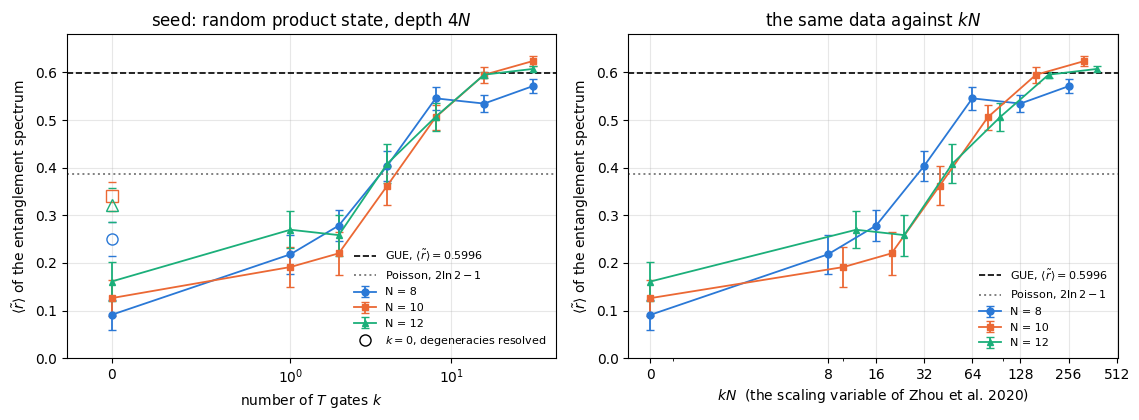

In [18]:
# ==============================================================================
# FIGURE 4: the entanglement spectrum turns from degenerate to Wigner-Dyson as T gates are added
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.3))
kk = np.array(K_LEV, dtype=float)
for i, N in enumerate(N_LEV):
    m = np.array([r[1] for r in lev[N][0]])
    e = np.array([r[2] for r in lev[N][0]])
    axes[0].errorbar(kk, m, yerr=e, color=PALETTE[i], marker=MARKERS[i], ms=5, lw=1.3, capsize=3, label=f"N = {N}")
    axes[1].errorbar(kk * N, m, yerr=e, color=PALETTE[i], marker=MARKERS[i], ms=5, lw=1.3, capsize=3, label=f"N = {N}")
    # the pure-Clifford point with its exact two-fold degeneracies resolved (open symbol)
    axes[0].errorbar([0.0], [lev[N][0][0][4]], yerr=[lev[N][0][0][5]], color=PALETTE[i], marker=MARKERS[i], ms=8,
                     mfc="none", lw=0, capsize=3, label="_nolegend_")
axes[0].errorbar([], [], color="k", marker="o", ms=8, mfc="none", lw=0,
                 label=r"$k=0$, degeneracies resolved")
for ax in axes:
    ax.axhline(R_GUE, color="k", ls="--", lw=1.2, label=r"GUE, $\langle \tilde r\rangle = 0.5996$")
    ax.axhline(R_POISSON, color="gray", ls=":", lw=1.4, label=r"Poisson, $2\ln 2-1$")
    ax.set_ylabel(r"$\langle \tilde r\rangle$ of the entanglement spectrum")
    ax.set_ylim(0.0, 0.68)
axes[0].set_xscale("symlog", linthresh=1)
axes[0].set_xlim(-0.25, 45)
axes[0].set_xlabel(r"number of $T$ gates $k$")
axes[0].set_title(rf"seed: random product state, depth ${DEPTH_FACTOR}N$")
axes[0].legend(fontsize=8, loc="lower right")
axes[1].set_xscale("symlog", linthresh=8)
axes[1].set_xlim(-1.0, 520)
axes[1].set_xticks([0, 8, 16, 32, 64, 128, 256, 512])
axes[1].set_xticklabels(["0", "8", "16", "32", "64", "128", "256", "512"])
axes[1].set_xlabel(r"$kN$  (the scaling variable of Zhou et al. 2020)")
axes[1].set_title("the same data against $kN$")
axes[1].legend(fontsize=8, loc="lower right")
fig.tight_layout()
plt.show()

### 7.3 What the measurement says

**The level statistics respond to the $T$ gates while the entropy does not.** The last printed block shows that the
half-chain entropy changes by at most $0.1$ bit over the whole range of $k$ ($3.37\to3.28$ bit at $N=8$,
$5.20\to5.26$ bit at $N=12$), while $\langle\tilde r\rangle$ moves from $0.09$ to $0.61$. That difference is the
quantitative content of "entanglement complexity" as distinct from the amount of entanglement.

**The raw Clifford value lies far below Poisson because of exact degeneracies.** At $k=0$ the estimator returns
$\langle\tilde r\rangle=0.09$, $0.13$, $0.16$ at $N=8,10,12$, far below $2\ln2-1=0.386$. The block printed under
"the pure-Clifford point looked at more closely" gives the reason: on average about half of the levels of a Clifford
spectrum sit in exactly degenerate pairs (the printed fractions are $0.63$, $0.63$, $0.50$; two independent runs with
$200$ realisations give $0.43$-$0.53$ at every $N$ from $8$ to $16$). Those pairs contribute $\tilde r=0$ by
construction and pull the average down. A degeneracy reflects a symmetry of the entanglement Hamiltonian and says
nothing about how the remaining levels are correlated.

Two controls support this diagnosis. First, running the same estimator with the degeneracies **resolved** (one level
kept per degenerate pair, the standard random-matrix prescription for a symmetry) gives $0.25$, $0.34$, $0.32$ here.
Two independent runs with $200$ realisations each give $0.25$-$0.28$ at $N=8$, $0.30$-$0.31$ at $N=12$, $0.31$-$0.36$ at
$N=14$ and $0.367$, $0.369$ ($\pm0.011$) at $N=16$, within two standard errors of $2\ln2-1$. The values do not rise
monotonically within one run, but the trend over $N=8$-$16$ is upward and ends at the Poisson value: the
non-degenerate part of a Clifford entanglement spectrum is consistent with uncorrelated levels. Second, replacing the
coplanar seed of Eq. (7) by one drawn from the **whole Bloch sphere** removes every degeneracy (the printed degenerate
fraction drops to exactly $0$), and the same pure-Clifford circuits then give $\langle\tilde r\rangle=0.437$,
$0.504$, $0.544$ at $N=8,10,12$, between Poisson and GUE. The degeneracy is therefore tied to the *coplanarity* of
the seed ($\langle Y_q\rangle=0$ on every site). The three papers of Section 7.1 use the coplanar seed, so the
degenerate pairs are present in their data too; none of them mentions them.

**The crossover.** The measured milestones at $N=12$: $\langle\tilde r\rangle=0.41\pm0.04$ at $k=4$ (it crosses the
Poisson value there), $0.51\pm0.03$ at $k=8$, and $0.595\pm0.006$ at $k=16$, statistically indistinguishable from
both the GUE value $0.5996$ and the $24$ exact Haar states measured at the same size ($0.604\pm0.007$). At $N=10$ the
GUE value is reached at $k=16$ as well. At $N=8$ the values for $k=8$-$32$ ($0.53$-$0.57$) lie one to three standard
errors below the Haar reference measured with the same estimator at the same size ($0.595\pm0.012$), so the small
number of levels ($16$) does not explain them; the approach to the Haar value is slower at $N=8$, and a run with $200$
realisations reaches it only near $k=64$.

The crossing of the Poisson value happens at $kN\approx48$ here ($N=12$, $k=4$), which is where the scaling function
of Zhou et al. (2020) crosses it too. Their variable is the product $kN$, and the right-hand panel plots our data that
way. At $N=8$-$12$ our three sizes cannot separate this scaling from a scaling with $k/N$: in a leave-one-size-out
collapse test the two variables fit equally well and the unscaled $k$ fits worse, and the size of the $\chi^2$
depends on the interpolation used while this ranking does not. We therefore do **not** claim a scaling variable from
this data.

A different threshold applies when the circuit starts from $\vert0\cdots0\rangle$. True and Hamma (2022) insert single
$T$ gates between long random Clifford blocks acting on $\vert0\cdots0\rangle$ and find that the distribution of gap
ratios approaches the GUE form only beyond $k_{\min}\approx N+2$ $T$ gates, a finite density of $T$ gates. They
attribute the difference to the seed: a random product state already carries $O(N)$ non-Clifford resources. Our
Section 9 starts from $\vert0\cdots0\rangle$ at $N=8$ (with the $T$ gates spread over a brick wall instead of being
separated by long Clifford blocks), and its doped column shows the same behaviour: $\langle\tilde r\rangle$ is
still $0.13$ at $k=8$ and reaches the GUE value only between $k=16$ and $k=32$.

> **Numerical practice.** Never report a level-statistics number without its null model — and make sure the null
> model has the density of the data you are testing, not of some other data set. The `surrogate(Haar)` row is the
> estimator applied to uncorrelated levels drawn from the *Haar* density, and it lands on the Poisson value
> ($0.392$, $0.393$, $0.401$). The `surrog.(k=0)` row repeats the construction with the *Clifford* density, which is
> far more structured, and returns $0.335$, $0.352$, $0.359$, so that density alone lowers the estimator by $0.03$ to
> $0.05$, and the Clifford-density surrogate is the correct zero for the $k=0$ column. Either way the null model sits
> five to eight combined standard errors *above* the raw $0.09$-$0.16$, which is why the degeneracy, and not the shape
> of $\rho_\xi$, explains the raw number.

## 8. Diagnostic 4: the output distribution

The three diagnostics so far all need the state vector. The fourth needs only *samples*, and it is the one that
hardware experiments actually measure.

### 8.1 Porter-Thomas statistics of a random state

For a Haar-random state the vector of amplitudes is a uniformly random unit vector in $\mathbb C^D$, $D=2^N$. The
probability $p_s=\lvert\psi_s\rvert^2$ of one fixed outcome is then distributed as $\mathrm{Beta}(1,D-1)$, whose
moments are

$$ \mathbb E[p_s]=\frac1D,\qquad \mathbb E[p_s^2]=\frac{2}{D(D+1)} , $$

and for large $D$ the rescaled probability $y=Dp_s$ becomes exponential, $\Pr(y)=e^{-y}$ — the **Porter-Thomas**
distribution. The rescaled collision probability of Eq. (2) follows immediately:

$$ \mathbb E\big[Z\big]=\mathbb E\Big[D\sum_sp_s^2\Big]=D\cdot D\cdot\frac{2}{D(D+1)}=\frac{2D}{D+1}\;\xrightarrow[D\to\infty]{}\;2 . \tag{5} $$

$Z=2$ is the standard statement that a random circuit output is *anticoncentrated*: the distribution is spread out, but
with fluctuations of order one relative to the mean. It is also the number that makes cross-entropy benchmarking work:
the linear XEB of a perfect device is $\mathcal F_{\rm XEB}=Z-1\approx1$
([notebook 10](../ch04_digital_quantum_circuits/10_random_unitaries_and_random_circuits.ipynb), Section 9).

### 8.2 The output distribution of a stabilizer state: derivation

Now repeat the calculation for a stabilizer state, using the projector formula of Section 6.2:

$$ p_s=\langle s\vert\psi\rangle\langle\psi\vert s\rangle=\frac1{2^N}\sum_{g\in\mathcal S}\langle s\vert g\vert s\rangle . $$

A Pauli string has a non-zero diagonal element in the computational basis only if it contains no $X$ and no $Y$, i.e.
only if it is **diagonal**; and a diagonal stabilizer element gives $\langle s\vert g\vert s\rangle=\pm1$. Let
$\mathcal S_Z\subseteq\mathcal S$ be the subgroup of diagonal elements, $\lvert\mathcal S_Z\rvert=2^m$. Then

$$ p_s=\frac{2^m}{2^N}\times\big[\,\text{all }g\in\mathcal S_Z\ \text{give}+1\ \text{on } s\,\big] , $$

because the characters $s\mapsto\langle s\vert g\vert s\rangle$ of the abelian group $\mathcal S_Z$ sum to
$\lvert\mathcal S_Z\rvert$ on the strings where all of them equal $+1$ and to zero elsewhere. The condition "all
diagonal stabilizers give $+1$" is a set of $m$ linear equations over $\mathbb F_2$, so the support of the distribution
is an **affine subspace** $\mathcal A\subset\mathbb F_2^N$ of dimension $N-m$ carrying $2^{N-m}$ strings, and the
distribution is **exactly uniform on it**: $p_s=2^{m-N}$ for $s\in\mathcal A$, $p_s=0$ otherwise. Hence

$$ Z=D\sum_sp_s^2=2^N\cdot2^{N-m}\cdot\big(2^{m-N}\big)^2=2^{m} . \tag{6} $$

Two consequences. First, $Z$ is an exact **power of two** for every stabilizer state. Second, $Z$ fluctuates from
circuit to circuit by factors of two, whereas for Haar-random states it concentrates at $2$. How often each $m$ occurs
for a *uniformly* random stabilizer state follows from counting. The diagonal Pauli strings, taken modulo signs, form
an $N$-dimensional subspace $L_Z$ of the $2N$-dimensional binary symplectic space, the stabilizer group modulo signs
is a Lagrangian subspace $L$ of the same dimension, and $m=\dim(L\cap L_Z)$. There are $\prod_{j=1}^N(2^j+1)$
Lagrangian subspaces. Those meeting $L_Z$ in a given $m$-dimensional subspace $W$ correspond to Lagrangian subspaces
of the $2(N-m)$-dimensional quotient $W^\perp/W$ transversal to $L_Z/W$, and these are the graphs of symmetric
$(N-m)\times(N-m)$ binary matrices, $2^{(N-m)(N-m+1)/2}$ of them. With $\binom{N}{m}_2$ the number of
$m$-dimensional subspaces of $\mathbb F_2^N$,

$$ P(m)=\binom{N}{m}_2\frac{2^{(N-m)(N-m+1)/2}}{\prod_{j=1}^N(2^j+1)},\qquad P(0)=\prod_{j=1}^N\frac{1}{1+2^{-j}}\;\xrightarrow[N\to\infty]{}\;0.419 . \tag{6a} $$

At $N=12$ this gives $P(0)=P(1)=0.42$, $P(2)=0.14$ and $P(3)=0.02$: $m=0$ (perfectly uniform output, $Z=1$) is the
most likely case, but it occurs in fewer than half of the states, and $m=1$ is just as likely. The mean comes out as
$\mathbb E[2^m]=2D/(D+1)$, *exactly* the Haar value of Eq. (5). This is no coincidence: the multi-qubit Clifford group
is a unitary $3$-design (Webb 2016; Zhu 2017), so the random stabilizer states reproduce the Haar averages of all
polynomials of degree up to three in $\vert\psi\rangle$ and in $\langle\psi\vert$, and $Z$ is of degree two. The
ensemble mean of $Z$, and with it the circuit-averaged linear XEB score $\mathbb E[Z]-1$ of a perfect device, cannot
tell a random Clifford circuit from a Haar-random one. The difference shows up in the distribution of $Z$ over
circuits, and in the fact that a stabilizer output distribution is uniform on an affine subspace, which a classical
computer samples exactly in polynomial time.

N = 12, D = 4096, depth 32, 24 realisations
Porter-Thomas prediction  Z = 2D/(D+1) = 1.999512
uniformly random stabilizer states, Eq. (6a): P(m=0..3) = [0.4195 0.4194 0.1397 0.0199];  E[2^m] = 1.999512
Clifford brick walls, measured frequencies of m = 0..3: [0.33333333 0.625      0.04166667 0.        ]

            family        <Z>       +-    log2 Z: all integers?          distinct log2 Z
          Clifford     1.7500   0.1350                     True                [0, 1, 2]
        doped, k=8     2.0084   0.1087                    False  -- not powers of two --
         universal     2.0326   0.0055                    False  -- not powers of two --
   Haar brick wall     1.9973   0.0060                    False  -- not powers of two --


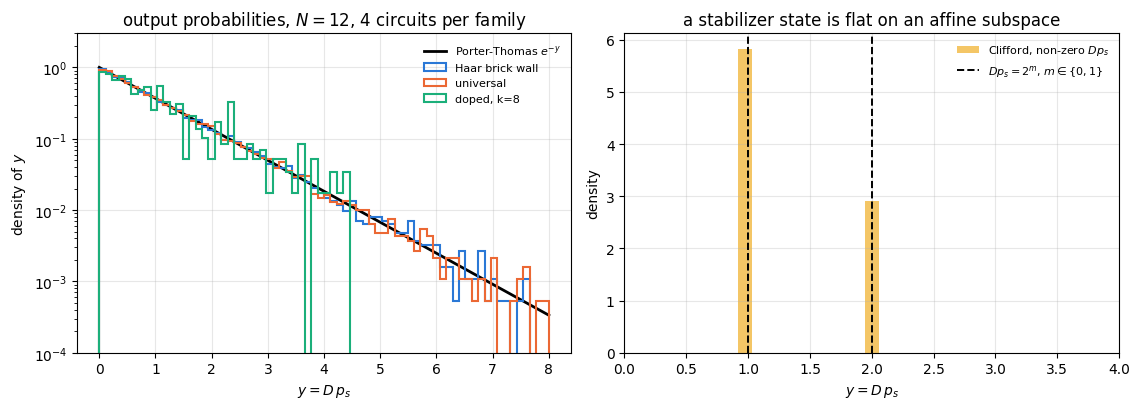


Z from the state vector: 2.0320
Z from 20000 sampled bit strings: 2.0486 +- 0.0107


In [19]:
# ==============================================================================
# STEP 10: output statistics -- Z = D sum p^2 and the Porter-Thomas histogram
# ==============================================================================
D_ENT = 2 ** N_ENT
Z_final = {lab: o[:, -1, 1] for lab, (o, _) in ent.items()}
print(f"N = {N_ENT}, D = {D_ENT}, depth {2 * ND_ENT}, {R_ENT} realisations")
print(f"Porter-Thomas prediction  Z = 2D/(D+1) = {2 * D_ENT / (D_ENT + 1):.6f}")


def n_subspaces_f2(n, m):
    """Gaussian binomial [n choose m]_2: the number of m-dimensional subspaces of F_2^n."""
    num, den = 1, 1
    for i in range(m):
        num, den = num * (2 ** (n - i) - 1), den * (2 ** (i + 1) - 1)
    return num // den


def p_diag_stabilizers(N):
    """Eq. (6a): probability that a uniformly random N-qubit stabilizer state has exactly m diagonal generators."""
    n_lagrangian = int(np.prod([2 ** j + 1 for j in range(1, N + 1)], dtype=object))
    return np.array([n_subspaces_f2(N, m) * 2 ** ((N - m) * (N - m + 1) // 2) / n_lagrangian for m in range(N + 1)])


P_m = p_diag_stabilizers(N_ENT)
EZ_stab = float(np.sum(P_m * 2.0 ** np.arange(N_ENT + 1)))
print(f"uniformly random stabilizer states, Eq. (6a): P(m=0..3) = {np.round(P_m[:4], 4)};  "
      f"E[2^m] = {EZ_stab:.6f}")
assert abs(P_m.sum() - 1) < 1e-12 and abs(EZ_stab - 2 * D_ENT / (D_ENT + 1)) < 1e-12   # 2-design: Haar value
m_cl = np.round(np.log2(np.asarray(Z_final["Clifford"]))).astype(int)
print(f"Clifford brick walls, measured frequencies of m = 0..3: {np.bincount(m_cl, minlength=4)[:4] / R_ENT}\n")
print(f"{'family':>18s} {'<Z>':>10s} {'+-':>8s} {'log2 Z: all integers?':>24s} {'distinct log2 Z':>24s}")
for lab, z in Z_final.items():
    l2 = np.log2(np.asarray(z))
    is_int = bool(np.max(np.abs(l2 - np.round(l2))) < 1e-9)
    show = sorted(set(np.round(l2).astype(int).tolist())) if is_int else []
    print(f"{lab:>18s} {z.mean():10.4f} {z.std() / np.sqrt(R_ENT):8.4f} {str(is_int):>24s} "
          f"{(str(show) if is_int else '-- not powers of two --'):>24s}")

# the full distribution of D p_s for one realisation of each family
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))
yg = np.linspace(0, 8, 300)
axes[0].plot(yg, np.exp(-yg), "k-", lw=2, label=r"Porter-Thomas $e^{-y}$")
for i, lab in enumerate(["Haar brick wall", "universal", f"doped, k={K_DOPE}"]):
    y = D_ENT * np.abs(np.asarray(ent[lab][1])[:4].reshape(-1)) ** 2
    axes[0].hist(y, bins=70, range=(0, 8), density=True, histtype="step", lw=1.5, color=PALETTE[i], label=lab)
axes[0].set_yscale("log")
axes[0].set_ylim(1e-4, 3)
axes[0].set_xlabel(r"$y = D\,p_s$")
axes[0].set_ylabel(r"density of $y$")
axes[0].set_title(rf"output probabilities, $N={N_ENT}$, 4 circuits per family")
axes[0].legend(fontsize=8)

y_cl = D_ENT * np.abs(np.asarray(ent["Clifford"][1])[:4].reshape(-1)) ** 2
axes[1].hist(y_cl[y_cl > 1e-9], bins=70, range=(0, 8), density=True, histtype="stepfilled", alpha=0.6,
             color=PALETTE[3], label="Clifford, non-zero $D p_s$")
m_plotted = sorted(set(m_cl[:4].tolist()))                    # m of the four plotted Clifford circuits
for j, mm in enumerate(m_plotted):
    axes[1].axvline(2.0 ** mm, color="k", ls="--", lw=1.4,
                    label=rf"$D p_s = 2^m$, $m \in \{{{', '.join(map(str, m_plotted))}\}}$" if j == 0 else None)
axes[1].set_xlim(0, 4)
axes[1].set_xlabel(r"$y = D\,p_s$")
axes[1].set_ylabel("density")
axes[1].set_title("a stabilizer state is flat on an affine subspace")
axes[1].legend(fontsize=8)
fig.tight_layout()
plt.show()

# CHECKPOINT 6: sampled bit strings must reproduce Z within the statistical error
psi_test = ent["universal"][1][0]
p_test = np.abs(np.asarray(psi_test).reshape(-1)) ** 2
bits = sample_bitstrings(jax.random.PRNGKey(4), psi_test, 20000)
weights = 2 ** np.arange(N_ENT - 1, -1, -1)
vals = D_ENT * p_test[np.asarray(bits) @ weights]
print(f"\nZ from the state vector: {D_ENT * np.sum(p_test ** 2):.4f}")
print(f"Z from 20000 sampled bit strings: {vals.mean():.4f} +- {vals.std() / np.sqrt(len(vals)):.4f}")
assert abs(vals.mean() - D_ENT * np.sum(p_test ** 2)) < 5 * vals.std() / np.sqrt(len(vals))

### 8.3 What the measurement says

Equation (6) is confirmed in the strongest possible form. For the Clifford family, $\log_2Z$ is an **integer for every
single realisation** (the printed check compares against $10^{-9}$), and the integers that occur in these $24$
circuits are $0$, $1$ and $2$. The case $m=0$, no diagonal stabilizer at all, means a *perfectly uniform*
distribution over all $4096$ bit strings. The measured frequencies of $m$ printed above ($8$, $15$ and $1$ of the
$24$ circuits for $m=0,1,2$) are within two binomial standard deviations of Eq. (6a) for uniformly random stabilizer
states (expected $10.1\pm2.4$, $10.1\pm2.4$ and $3.4\pm1.7$); repeating the draw with $200$ circuits gives
$m=0,1,2,3$ in $47\%$, $41\%$, $10\%$, $2\%$ of them in one run and $40.5\%$, $45.5\%$, $11\%$, $2.5\%$ in another,
against $42\%$, $42\%$, $14\%$, $2\%$ from Eq. (6a) (Exercise 3). The ensemble mean $1.75\pm0.14$ is the average of
$2^m$ over these $24$ circuits; it lies $1.8$ standard errors below the exact average $2D/(D+1)$ of Eq. (6a).
For the other three families $\log_2Z$ is never an integer. The doped family, $2.008\pm0.109$, and the Haar brick
wall, $1.997\pm0.006$, agree with the Porter-Thomas prediction $2D/(D+1)=1.9995$; the universal family,
$2.033\pm0.006$, is $6$ standard errors above it, the same incomplete convergence at depth $32$ that Section 6.4 saw
in $x_{\max}$. The right-hand panel shows the mechanism: the non-zero rescaled probabilities of a stabilizer state
take *only* the value $2^m$ of its circuit, while the other families fill an exponential distribution over four
decades. The standard errors also differ: $0.135$ for the Clifford family against $0.006$ for the Haar brick wall,
because $Z$ of a stabilizer state jumps between powers of two from circuit to circuit.

For sampling-based advantage claims this has a sharp consequence. The linear cross-entropy fidelity of a perfect
device is $\mathcal F_{\rm XEB}=Z-1=2^m-1$ for a Clifford circuit: $0$ for the circuits with $m=0$, the score of a
device that outputs uniform random bits, and $1$ or more for the others. Averaged over random Clifford circuits it
equals the Haar average $(D-1)/(D+1)$, because the Clifford group is a $3$-design. A good XEB score therefore cannot,
by itself, certify that a device ran a hard circuit: a random Clifford circuit reaches the same average score, and its
output, uniform on an affine subspace, is sampled exactly by a classical computer in polynomial time. At the same
time the state carries $5.04$ bits of half-chain entanglement; at large $N$ that volume-law entanglement rules out an
efficient matrix product state.

The sampling checkpoint closes the loop: $20\,000$ bit strings drawn from one universal circuit give
$Z=2.049\pm0.011$ against the exact $2.032$ computed from the amplitudes, so the quantity really is measurable from
shots alone.

## 9. The complexity diagram

We now put the four diagnostics on the same set of states: a random product state (no entanglement), a Clifford
circuit on $\lvert0\dots0\rangle$ (a random stabilizer state), $N/2$ Bell pairs straddling the cut (the *maximally*
entangled stabilizer state), $T$-doped circuits with growing $k$, a universal circuit, and exact Haar-random states.
The size is $N=8$ so that the $O(N4^N)$ magic is affordable for every family.

In [20]:
# ==============================================================================
# STEP 11: all four diagnostics on the same families
# ==============================================================================
# bell_pairs_across_cut: copied verbatim from notebook 27 (Section 10.2).
def bell_pairs_across_cut(N):
    """Stabilizer state with the MAXIMAL half-chain entropy: N/2 Bell pairs, each straddling the cut.

    MATH   |psi> = (x)_{q<N/2} (|0_q 0_{q+N/2}> + |1_q 1_{q+N/2}>)/sqrt(2);  S(N/2) = N/2 bits exactly,
           and every stabiliser generator is a Pauli string, so M_alpha = 0.
    """
    psi = zero_state(N)
    for q in range(N // 2):
        psi = apply_gate(apply_gate(psi, H, [q]), CNOT, [q, q + N // 2])
    return psi


# ------------------------------- PARAMETERS ----------------------------------
N_CD, R_CD = 8, 16                 # qubits, realisations per family
ND_CD = 2 * N_CD                   # double layers -> depth 4N
# -----------------------------------------------------------------------------
keys_cd = jax.random.split(jax.random.PRNGKey(1234), R_CD)
run_cd = jax.jit(jax.vmap(lambda g: run_brickwall_1q(zero_state(N_CD), g, half_chain_diagnostics)))
spec_cd = jax.jit(jax.vmap(lambda p: schmidt_values(p, list(range(N_CD // 2))) ** 2))
t0 = time.perf_counter()

fam = {}
fam["random product"] = jnp.stack([random_real_product_state(k, N_CD)
                                   for k in jax.random.split(jax.random.PRNGKey(11), R_CD)])
fam["Bell pairs"] = jnp.stack([bell_pairs_across_cut(N_CD)] * R_CD)
for k in (0, 2, 4, 8, 16, 32):
    masks = t_masks(jax.random.PRNGKey(500 + k), R_CD, 2 * ND_CD, N_CD, k)
    G = jax.vmap(lambda a, m: clifford_gate_array(a, m, 2 * ND_CD, N_CD))(keys_cd, masks)
    lab = "Clifford" if k == 0 else f"doped, k={k}"
    fam[lab] = run_cd(G.reshape(R_CD, ND_CD, 2, N_CD, 2, 2))[0]
G = jax.vmap(lambda a: haar_gate_array(a, 2 * ND_CD, N_CD))(keys_cd)
fam["universal"] = run_cd(G.reshape(R_CD, ND_CD, 2, N_CD, 2, 2))[0]
fam["Haar states"] = jnp.stack([haar_state(k, N_CD) for k in jax.random.split(jax.random.PRNGKey(12), R_CD)])

S_page_cd = page_entropy_bits(2 ** (N_CD // 2), 2 ** (N_CD - N_CD // 2))
M2_haar_cd = float(np.log2((2 ** N_CD + 3) / 4))
diagram = {}
print(f"N = {N_CD}, depth {2 * ND_CD}, {R_CD} realisations per family "
      f"(Page {S_page_cd:.3f} bit, Haar magic {M2_haar_cd:.3f} bit)\n")
print(f"{'family':>16s} {'S [bit]':>16s} {'M_2 [bit]':>16s} {'Z = D sum p^2':>16s} {'<r>':>16s}")
for lab, psis in fam.items():
    p = np.asarray(spec_cd(psis))
    S_v = np.array([-np.sum(r[r > 1e-16] * np.log2(r[r > 1e-16])) for r in p])
    M_v = sre_batch_of_states(psis)
    Z_v = np.asarray(2 ** N_CD * jnp.sum(jnp.abs(psis.reshape(R_CD, -1)) ** 4, axis=1))
    r_m, r_e = gap_ratio_ensemble(p)
    diagram[lab] = (S_v, M_v, Z_v, r_m, r_e)
    r_txt = "  undefined" if not np.isfinite(r_m) else f"{r_m:9.3f} +-{r_e:5.3f}"
    print(f"{lab:>16s} {S_v.mean():9.3f} +-{S_v.std() / np.sqrt(R_CD):5.3f} "
          f"{M_v.mean():9.3f} +-{M_v.std() / np.sqrt(R_CD):5.3f} "
          f"{Z_v.mean():9.3f} +-{Z_v.std() / np.sqrt(R_CD):5.3f} {r_txt:>16s}")
print("\n(<r> is undefined for the product state: its reduced density matrix has rank 1, so there are no levels.)")
for lab in ("doped, k=2", "doped, k=4"):                 # few T gates on |0...0>: how many DISTINCT levels?
    p = np.asarray(spec_cd(fam[lab]))
    n_dist = [len(np.unique(np.round(r[r > 1e-12] * 2 ** (N_CD // 2), 8))) for r in p]
    print(f"{lab}: number of distinct non-zero entanglement levels per realisation: {min(n_dist)} to {max(n_dist)}")
print(f"({time.perf_counter() - t0:.1f} s)")

# CHECKPOINT 7: the three exactly-known corners of the diagram
assert abs(diagram["random product"][0].mean()) < 1e-12                     # product state: S = 0 exactly
assert abs(diagram["Bell pairs"][0].mean() - N_CD / 2) < 1e-12              # Bell pairs: S = N/2 exactly
for lab in ("Bell pairs", "Clifford"):
    assert np.max(np.abs(diagram[lab][1])) < 1e-9                           # stabilizer states: M_2 = 0
    assert diagram[lab][3] == 0.0                                           # ... and a flat spectrum: <r~> = 0
assert np.max(np.abs(diagram["Bell pairs"][2] - 2 ** (N_CD // 2))) < 1e-9   # Eq. (6) with m = N/2 diagonal stabilizers
print("CHECKPOINT 7 passed: S=0 for the product state, S=N/2 and Z=2^{N/2} for the Bell state, "
      "M_2 = 0 and <r~> = 0 for both stabilizer families.")

N = 8, depth 32, 16 realisations per family (Page 3.282 bit, Haar magic 6.017 bit)

          family          S [bit]        M_2 [bit]    Z = D sum p^2              <r>


  random product     0.000 +-0.000     1.516 +-0.112    17.353 +-2.805        undefined
      Bell pairs     4.000 +-0.000     0.000 +-0.000    16.000 +-0.000     0.000 +-0.000
        Clifford     3.125 +-0.195     0.000 +-0.000     2.125 +-0.329     0.000 +-0.000
      doped, k=2     3.032 +-0.145     0.778 +-0.034     2.219 +-0.266     0.000 +-0.000
      doped, k=4     3.106 +-0.098     1.549 +-0.076     1.879 +-0.121     0.000 +-0.000
      doped, k=8     3.222 +-0.069     2.970 +-0.071     2.269 +-0.198     0.125 +-0.052
     doped, k=16     3.211 +-0.048     4.874 +-0.114     1.934 +-0.053     0.481 +-0.061
     doped, k=32     3.233 +-0.031     5.918 +-0.023     2.037 +-0.043     0.602 +-0.018


       universal     3.278 +-0.017     6.015 +-0.004     1.977 +-0.033     0.613 +-0.017
     Haar states     3.282 +-0.010     6.013 +-0.004     2.013 +-0.036     0.602 +-0.026

(<r> is undefined for the product state: its reduced density matrix has rank 1, so there are no levels.)
doped, k=2: number of distinct non-zero entanglement levels per realisation: 1 to 2
doped, k=4: number of distinct non-zero entanglement levels per realisation: 1 to 4
(3.1 s)
CHECKPOINT 7 passed: S=0 for the product state, S=N/2 and Z=2^{N/2} for the Bell state, M_2 = 0 and <r~> = 0 for both stabilizer families.


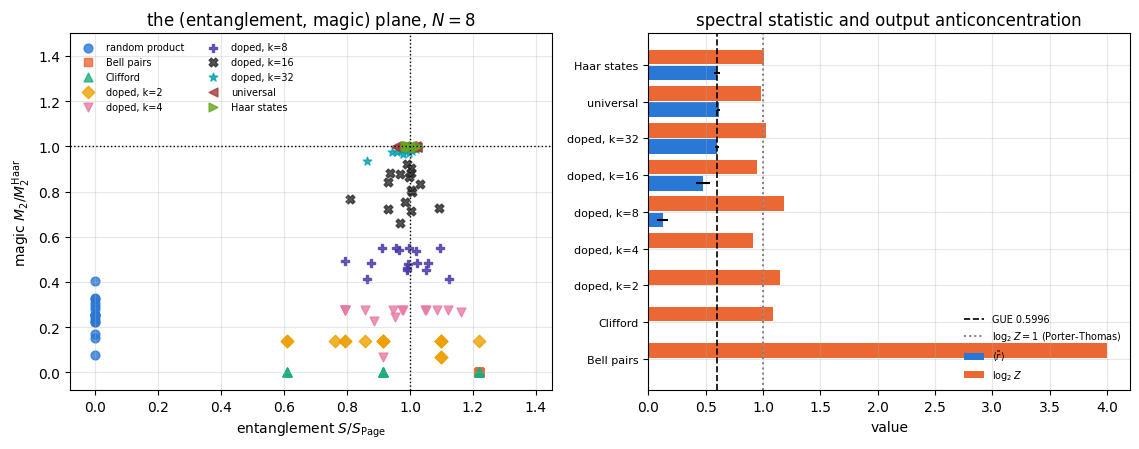

In [21]:
# ==============================================================================
# FIGURE 5: the complexity diagram -- entanglement against magic, with the spectral statistic
# ==============================================================================
PALETTE10 = PALETTE + ["#2b2b2b", "#00a0b0", "#a33b3b", "#66a61e"]     # 10 families need 10 distinguishable styles
MARKERS10 = MARKERS + ["X", "*", "<", ">"]
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6))
for i, (lab, (S_v, M_v, Z_v, r_m, r_e)) in enumerate(diagram.items()):
    axes[0].scatter(S_v / S_page_cd, M_v / M2_haar_cd, s=40, marker=MARKERS10[i], color=PALETTE10[i],
                    alpha=0.8, label=lab)
axes[0].axvline(1.0, color="k", ls=":", lw=1)
axes[0].axhline(1.0, color="k", ls=":", lw=1)
axes[0].set_xlabel(r"entanglement $S/S_{\mathrm{Page}}$")
axes[0].set_ylabel(r"magic $M_2/M_2^{\mathrm{Haar}}$")
axes[0].set_title(rf"the (entanglement, magic) plane, $N={N_CD}$")
axes[0].legend(fontsize=7, loc="upper left", ncol=2)
axes[0].set_xlim(-0.08, 1.45)
axes[0].set_ylim(-0.08, 1.50)

labels = [l for l in diagram if np.isfinite(diagram[l][3])]
ypos = np.arange(len(labels))
axes[1].barh(ypos - 0.22, [diagram[l][3] for l in labels], height=0.4, color=PALETTE[0],
             xerr=[diagram[l][4] for l in labels], label=r"$\langle \tilde r\rangle$")
axes[1].barh(ypos + 0.22, [np.log2(diagram[l][2].mean()) for l in labels], height=0.4, color=PALETTE[1],
             label=r"$\log_2 Z$")
axes[1].axvline(R_GUE, color="k", ls="--", lw=1.2, label="GUE 0.5996")
axes[1].axvline(1.0, color="gray", ls=":", lw=1.4, label=r"$\log_2 Z = 1$ (Porter-Thomas)")
axes[1].set_yticks(ypos)
axes[1].set_yticklabels(labels, fontsize=8)
axes[1].set_xlabel("value")
axes[1].set_title("spectral statistic and output anticoncentration")
axes[1].legend(fontsize=7, loc="lower right")
fig.tight_layout()
plt.show()

### 9.1 Reading the diagram

The scatter plot has four corners, and every one of them is occupied by a family that a naive one-number criterion
would misclassify.

* **Bottom left — the random product state.** $S=0$ exactly, $M_2=1.52\pm0.11$ bit: magic without any entanglement.
  Trivially simulable (it is a product of $2\times2$ vectors), yet a stabilizer simulator cannot touch it.
  Its entanglement spectrum has a single level, so $\langle\tilde r\rangle$ is not even defined.
* **Bottom right — the stabilizer states.** $N/2$ Bell pairs across the cut give $S=4.000$ bits, the *maximum*
  possible at $N=8$ — $22\%$ above the Page value — with $M_2=0$ exactly. The random Clifford circuit gives
  $S=3.13\pm0.20$, i.e. $95\%$ of the Page value, again with $M_2=0$. Both are simulated in $O(N)$ per Clifford gate.
  Both have $\langle\tilde r\rangle=0.000$ exactly: flat spectra, no level structure at all.
* **The diagonal — doping.** $k=2,4,8,16,32$ climb the magic axis ($0.78$, $1.55$, $2.97$, $4.87$, $5.92$ bit) at
  constant entanglement ($3.03$ to $3.23$ bit), and the spectral statistic follows the magic while the entanglement
  stays constant: $0.000$, $0.000$, $0.125$, $0.481$, $0.602$. The two zeros have a simple origin. These circuits
  start from $\lvert0\dots0\rangle$, a stabilizer state, and at $k=2$ and $k=4$ the output spectrum still consists of
  only a few distinct, highly degenerate levels (the printed counts), so every gap ratio in the bulk is zero, even
  though the state already carries $0.78$ and $1.55$ bit of magic: a couple of $T$ gates create magic long before they
  create level repulsion in the entanglement spectrum. Section 7 avoids this by seeding with a non-stabilizer product
  state, which is why its $k=2$ and $k=4$ columns are non-zero.
* **Top right — universal and Haar.** $S/S_{\rm Page}=0.999$ and $1.000$, $M_2/M_2^{\rm Haar}=1.000$,
  $\langle\tilde r\rangle=0.613\pm0.017$ and $0.602\pm0.026$, $Z\approx2$. The universal brick wall at depth $4N$ is
  statistically indistinguishable from a Haar-random state in all four diagnostics.

The bar panel adds the two remaining numbers (the product state is left out of it, having no level statistics). The
Bell-pair state has $\log_2Z=4$ exactly — it has precisely $N/2=4$ diagonal stabilizers $Z_qZ_{q+N/2}$, so Eq. (6)
predicts $Z=2^4=16$, and $16.000\pm0.000$ is what is measured. The random product state, in the printed table, has
$Z=17.35$, i.e. $\log_2Z=4.12$, not an integer, because it is not a stabilizer state: magic alone does not make an
output distribution anticoncentrated. The circuit outputs all sit near $\log_2Z=1$, the Porter-Thomas value,
including the random Clifford family ($Z=2.13\pm0.33$): as Section 8.2 showed, the ensemble mean of $Z$ over random
stabilizer states equals the Haar value, and only the realisation-by-realisation values ($Z=2^m$) differ.

**No single axis of this diagram is "complexity".** A state in the bottom-right corner is maximally entangled and
free; a state in the bottom-left corner is full of magic and free. Only the top-right corner is hard for all the
algorithms of Section 2 at once, and even then "hard" means "hard for the methods we know", and makes no statement
about $\mathcal C(\psi)$.

## 10. What each diagnostic costs, and how far it reaches

Every number in this notebook has a price, and the prices are wildly different.

| diagnostic | algorithm | time | memory | practical limit here |
|---|---|---|---|---|
| circuit execution | one einsum per gate | $O(2^N)$ per gate | $16\cdot2^N$ bytes | $N\approx20$ |
| half-chain entropy / spectrum | one SVD of a $2^{N/2}\times2^{N/2}$ matrix | $O((2^{N/2})^3)=O(2^{3N/2})$ | $O(2^N)$ | $N\approx20$ |
| collision probability $Z$ | one pass over the amplitudes | $O(2^N)$ | $O(2^N)$ | $N\approx24$ |
| magic $M_2$ | Walsh-Hadamard over all $X$-patterns | $O(N4^N)$ | $O(\text{batch}\cdot2^N)$ | $N\approx12\text{-}14$ |
| magic $M_2$, brute force | all $4^N$ Pauli expectation values | $O(8^N)$ | $O(2^N)$ | $N\approx6$ |

The magic is the expensive one, and it is the reason Section 5 runs at $N=8$ while Section 4 runs at $N=12$. The cell
below measures the three curves that matter.

run times are the best of repeated calls after compilation; 'compile' = first call minus that run time

  N  state (MB)  circuit, 8 layers (s)  compile (s)  half-chain SVD (s)   magic M_2 (s)  compile (s)          4^N


  6      0.0010                0.00046        0.102             0.00004          0.0007        0.000         4096


  8      0.0041                0.00022        0.122             0.00003          0.0023        0.000        65536


 10      0.0164                0.00060        0.140             0.00006          0.0305        0.158      1048576


 12      0.0655                0.00243        0.195             0.00020          0.7324        0.157     16777216


 14      0.2621                0.01002        0.219             0.00109         skipped            -    268435456
magic: cost ratio per two added qubits = 3x (6->8), 13x (8->10), 24x (10->12);  the N 4^N law predicts 19x for the last step


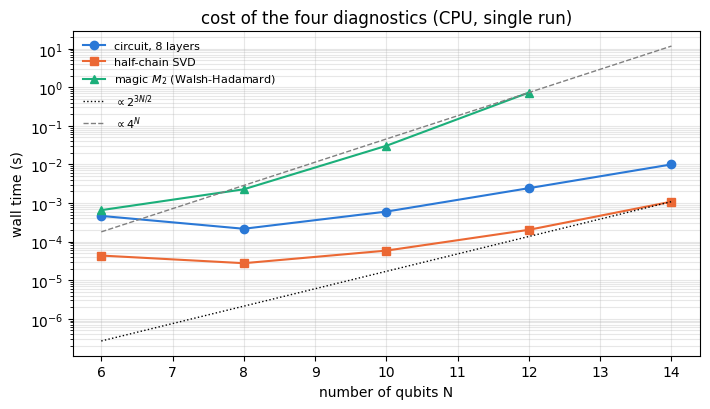

In [22]:
# ==============================================================================
# STEP 12: measured cost of the diagnostics versus system size
# ==============================================================================
def timed(fn, arg, repeats=3):
    """Run once to compile, then time `repeats` calls; returns (compile+first call, best run) in seconds."""
    t0 = time.perf_counter()
    jax.block_until_ready(fn(arg))
    t_first = time.perf_counter() - t0
    best = np.inf
    for _ in range(repeats):
        t0 = time.perf_counter()
        jax.block_until_ready(fn(arg))
        best = min(best, time.perf_counter() - t0)
    return t_first, best


print("run times are the best of repeated calls after compilation; 'compile' = first call minus that run time\n")
print(f"{'N':>3s} {'state (MB)':>11s} {'circuit, 8 layers (s)':>22s} {'compile (s)':>12s} {'half-chain SVD (s)':>19s} "
      f"{'magic M_2 (s)':>15s} {'compile (s)':>12s} {'4^N':>12s}")
cost_rows = []
for N in (6, 8, 10, 12, 14):
    g = haar_gate_array(jax.random.PRNGKey(N), 8, N).reshape(4, 2, N, 2, 2)
    circ_fn = jax.jit(lambda gg, N=N: run_brickwall_1q(zero_state(N), gg, half_chain_diagnostics)[0])
    t_first_circ, t_circ = timed(circ_fn, g)
    psi_t = circ_fn(g)
    svd_fn = jax.jit(lambda p, N=N: schmidt_values(p, list(range(N // 2))))
    _, t_svd = timed(svd_fn, psi_t)
    if N <= 12:
        t0 = time.perf_counter()
        sre(psi_t)
        t_first_sre = time.perf_counter() - t0
        t0 = time.perf_counter()
        sre(psi_t)
        t_sre = time.perf_counter() - t0
    else:
        t_sre, t_first_sre = np.nan, np.nan
    cost_rows.append((N, t_circ, t_svd, t_sre))
    print(f"{N:3d} {16 * 2 ** N / 1e6:11.4f} {t_circ:22.5f} {t_first_circ - t_circ:12.3f} {t_svd:19.5f} "
          f"{(f'{t_sre:.4f}' if np.isfinite(t_sre) else 'skipped'):>15s} "
          f"{(f'{t_first_sre - t_sre:.3f}' if np.isfinite(t_sre) else '-'):>12s} {4 ** N:12d}")

cost = np.array(cost_rows, dtype=float)
_t_sre = cost[np.isfinite(cost[:, 3]), 3]
print("magic: cost ratio per two added qubits = "
      + ", ".join(f"{_t_sre[i + 1] / _t_sre[i]:.0f}x ({int(cost[i, 0])}->{int(cost[i + 1, 0])})"
                  for i in range(len(_t_sre) - 1))
      + f";  the N 4^N law predicts {12 / 10 * 16:.0f}x for the last step")
fig, ax = plt.subplots(figsize=(7.2, 4.2))
ax.semilogy(cost[:, 0], cost[:, 1], "o-", color=PALETTE[0], label="circuit, 8 layers")
ax.semilogy(cost[:, 0], cost[:, 2], "s-", color=PALETTE[1], label="half-chain SVD")
ok = np.isfinite(cost[:, 3])
ax.semilogy(cost[ok, 0], cost[ok, 3], "^-", color=PALETTE[2], label=r"magic $M_2$ (Walsh-Hadamard)")
Nref = cost[:, 0]
ax.semilogy(Nref, cost[-1, 2] * 2.0 ** (1.5 * (Nref - Nref[-1])), "k:", lw=1, label=r"$\propto 2^{3N/2}$")
ax.semilogy(Nref, cost[ok, 3][-1] * 4.0 ** (Nref - Nref[ok][-1]), color="gray", ls="--", lw=1, label=r"$\propto 4^{N}$")
ax.set_xlabel("number of qubits N")
ax.set_ylabel("wall time (s)")
ax.set_title("cost of the four diagnostics (CPU, single run)")
ax.legend(fontsize=8)
ax.grid(alpha=0.3, which="both")
fig.tight_layout()
plt.show()

The measured curves say which diagnostic sets the limit. Executing the circuit and taking the SVD are so cheap at
these sizes that they are dominated by fixed overheads — one kernel launch per gate, one LAPACK call — and grow far
more slowly than the asymptotic $2^N$ and $2^{3N/2}$ lines drawn for reference: at $N=14$ a whole 8-layer circuit and
a half-chain SVD together take about $10^{-2}$ s. The magic is a different animal. It starts below $10^{-3}$ s at
$N=6$ and costs of order a second at $N=12$. The cell prints the cost ratio per two added qubits: it starts at only
a few (the small sizes are still dominated by fixed overheads) and is largest for the step $N=10\to12$, the first
asymptotic one. The $N4^N$ law predicts $\tfrac{12}{10}\cdot16=19$ for that step; repeated builds give $20$-$35$,
fluctuating with the load of the machine; the excess over $19$ is presumably memory traffic, since the
Walsh-Hadamard step touches `batch` copies of the state, but it was not measured separately. Extrapolating a factor
of $\sim25$, one state at $N=14$ costs of order half a minute, so a single $16$-realisation ensemble of Section 9
would cost about ten minutes and the ten families of the complexity diagram more than an hour. That is why every
magic measurement here runs at $N=8$. The compile columns show the one-off cost of tracing and compiling each
function for a new $N$, a few tenths of a second; it is paid once per system size, is excluded from the run times,
and is zero for the magic at $N=6$ and $8$ because earlier cells have already compiled the kernel for those sizes.
(Absolute times depend on the machine and its load; the scaling does not.)

> **Numerical practice.** The level statistics carry a finite-size caveat that no amount of CPU time removes. A
> half-chain cut of $N$ qubits has at most $2^{N/2}$ entanglement levels: $16$ at $N=8$, $64$ at $N=12$, $1024$ at
> $N=20$. A spectral statistic estimated from $64$ levels has a standard error of a few $10^{-2}$ per realisation even
> before any systematic effect, and the two "universal" reference values differ by only $0.21$. This is why the
> measurements of Section 7 average over realisations and quote standard errors, why they discard the outer $10\%$ of
> each spectrum (the edges are not in the random-matrix bulk), and why the uncorrelated surrogate is run alongside: at
> these sizes the statistic is at the limit of what it can resolve, and it must be calibrated rather than trusted.

## 11. Key takeaways

* **Hardness is always relative to an algorithm.** A matrix product state is defeated by entanglement
  ($\chi\ge2^{S}$), a stabilizer simulator by magic (cost exponential in the $T$ count), a sampling argument by
  anticoncentration. A state is hard for everything we know only if it has all three.
* **Entanglement alone does not separate the gate sets.** At $N=12$ and depth $32$ the four gate sets end up within
  $0.23$ bit of each other, under $5\%$ of the Page value $5.28$ bit, and at $N=8$ the $N/2$ Bell pairs, a stabilizer
  state simulated in $O(N)$ per Clifford gate, exceed the Page value by $22\%$.
* **A stabilizer state has an exactly flat entanglement spectrum**, $\rho_A=2^{a-n_A}\Pi_A$: one level with
  multiplicity $2^{S}$, an integer entropy in bits, and every Renyi entropy equal. Measured to $10^{-13}$, with
  Schmidt ranks $16,32,64$ and entropies $4,5,6$ bits exactly.
* **Magic is local and immediate, entanglement is non-local and slow.** One double layer of the universal circuit
  (two layers of Haar single-qubit gates and two CZ layers) already puts $3.15$ of the $6.02$ available bits of $M_2$
  on $N=8$ qubits, while the entanglement is at a fifth of the Page value; a Clifford circuit keeps $M_2=0$ at every
  depth, exactly. With $k$ $T$ gates in a shallow brick wall the magic stays below the law of Leone, Oliviero and
  Hamma: most of the distance from $k\log_2\frac43$ is saturation, the rest is the crowding of the $T$ gates.
* **A Haar-random state has a Marchenko-Pastur spectrum.** The Haar brick wall reaches a Kolmogorov distance of
  $0.0084$ from the MP law, against $0.0066$ for exact Haar states and $0.42$ for the Clifford family.
* **The level statistics of the entanglement spectrum respond to the $T$ gates while the entropy does not.** Doping a
  Clifford circuit seeded with a random product state with $k$ $T$ gates moves $\langle\tilde r\rangle$ from
  $\approx0.1$ to the GUE value $0.5996$ while the half-chain entropy changes by at most $0.1$ bit. It crosses the
  Poisson value at $kN\approx50$, as in Zhou et al. (2020), and reaches the GUE value at $k=16$ for $N=10$ and $12$;
  at $N=8$-$12$ our data cannot say whether $k/N$ or $kN$ is the scaling variable. Seeded with
  $\vert0\cdots0\rangle$, the circuit needs more $T$ gates, as True and Hamma (2022) found ($k_{\min}\approx N+2$).
* **The undoped Clifford value, $0.09$-$0.16$, comes from exact degeneracies.** About half the levels sit in exactly
  degenerate pairs when the seed has *coplanar* Bloch vectors. With one level kept per pair the value rises to about
  $0.37$ at $N=16$, close to the Poisson value $0.386$; a seed from the whole Bloch sphere has no degeneracies at all.
* **A random Clifford output is uniform on an affine subspace**, $Z=2^m$ in every realisation, with $m$ distributed as
  in Eq. (6a) ($m=0$ and $m=1$ each with probability $0.42$). The ensemble mean of $Z$, and hence the average linear
  XEB score, equals the Haar value because the Clifford group is a $3$-design, so an XEB average alone cannot
  distinguish these classically simulable circuits from hard ones.
* **None of this is circuit complexity.** $\mathcal C(\psi)$, the minimal gate count, is not computable at these
  sizes; the four diagnostics are witnesses. What is proved about complexity itself for random circuits is the linear
  growth of the exact complexity (Haferkamp et al. 2022) and of a robust complexity for a long time (Brandão et al.
  2021), the rigorous counterparts of the Brown-Susskind conjecture.

## 12. Exercises

**1. (★) The flat-spectrum theorem on paper.** Take the 3-qubit GHZ state with stabilizers
$\langle XXX, ZZ\mathbb 1, \mathbb 1ZZ\rangle$ and the cut $A=\{0\}$. Identify $\mathcal S_A$, compute $a$, and predict
the Schmidt rank and the entropy. Verify with `schmidt_values(ghz_state(3), [0])`. Repeat for the 4-qubit cluster state
with $A=\{0,1\}$ using `cluster_state(4)`.

**2. (★) Integer entropies.** Run the Clifford family of Section 4 for $N=8,10,12$ and collect the half-chain
entropies of all realisations. Show that they are integers, histogram them, and compare the mean with the Page value.
Determine the deficit and whether it grows with $N$; make sure the depth is large enough for the mean to have
saturated. (Check values with $200$ realisations: at depth $96$ the mean is $3.18$, $4.16$ and $5.19$ bit at
$N=8,10,12$, about $0.1$ bit below the Page value at every $N$ and about $0.8$ bit below $N/2$; at depth $32$, $N=12$
gives $4.9$-$5.0$ bit and has not saturated. At $N=12$ the entropies $2$ to $6$ bit occur, with $5$ the most
frequent.)

**3. (★★) Counting the diagonal stabilizers.** For `bell_pairs_across_cut(N)` write down the $N$ stabilizer
generators explicitly, identify the $m$ diagonal ones, and check that $Z=2^m$ as Eq. (6) predicts (Section 9 measures
$Z=16$ at $N=8$). Then apply a random Clifford brick wall to the same state and follow how $Z$ changes. Finally, run
the Clifford family of Section 4 with $200$ realisations, histogram $\log_2Z$, and measure the probability that a
random stabilizer state has no diagonal stabilizer at all. Compare the frequencies of $m$ with Eq. (6a). (Check
values: two runs gave $m=0$ in $47\%$ and $40.5\%$ of the circuits; Eq. (6a) gives $42\%$.)

**4. (★★) Doping density instead of doping number.** Section 7 inserts $k$ $T$ gates into a circuit of $4N$ layers.
Re-run the measurement at fixed *density* (a fixed probability that any given slot carries a $T$) rather than fixed
$k$, and plot $\langle\tilde r\rangle$ against the density for the three sizes. Check whether the curves collapse,
and explain the result in terms of the scaling variables of Section 7.3. (Check values with $24$ realisations and
slot probability $0.01$: $\langle\tilde r\rangle=0.33$, $0.37$, $0.51$ at $N=8,10,12$, with on average $2.4$, $3.7$
and $5.7$ $T$ gates. The curves do not collapse in the density: at fixed density the number of $T$ gates grows as
$4N^2$, so larger systems cross over at smaller density.)

**5. (★★) Marchenko-Pastur at an unequal cut.** Recompute Figure 3 for $n_A=N/2-2$, so that $\gamma=d_A/d_B=1/16$ and
the support $[x_-,x_+]$ is bounded away from zero. The square-root edges at both ends should now be clearly visible.
Measure the position of the upper edge and compare with $(1+\sqrt\gamma)^2$.

**6. (★★ extend the code) The second Renyi entropy as a diagnostic.** Add $S_2=-\log_2\sum_jp_j^2$ to
`half_chain_diagnostics` and plot $S-S_2$ against depth for the four families. For a stabilizer state the difference
is exactly zero (Section 6.2, corollary 3). Measure how large it gets for the universal circuit and compare it with
the Page-value deficit. (Check values at $N=12$, depth $32$: $S-S_2=0$ to $10^{-12}$ for Clifford, $0.22\pm0.02$ bit
for the doped family with $k=8$, $0.338\pm0.005$ bit for the universal family; exact Haar states give $0.279$ bit,
with $S_2=-\log_2\frac{d_A+d_B}{d_Ad_B+1}=5.0004$ bit, against a Page deficit of $0.721$ bit.)

**7. (★★★ extend the code) A disentangling algorithm.** Implement the disentangling search of Chamon, Hamma and
Mucciolo. Starting from the final state, propose one gate drawn at random from the same gate set the circuit was
built from, and accept it with probability $\min\{1,e^{-\kappa\Delta S}\}$ where $S=\sum_{n_A=1}^{N-1}S_2(n_A)$ is the
sum of the second Renyi entropies over *all* contiguous cuts (summing over cuts makes the search sensitive to a gate
acting anywhere; Shaffer et al. use $\kappa=5$, Chamon et al. increase $\kappa$ with the number of attempts). Chamon
et al. minimise the Renyi-0 entropy $S_0=\log_2(\text{Schmidt rank})$ and report similar results with $S_2$; for the
brick walls of this notebook seeded with a random product state, $S_0$ is maximal on every cut and no single gate
lowers it, so the $S_0$ search does not move, and $S_2$ is the usable cost. Run the search on the Clifford family and
on the doped family, compare the residual entropy, and relate success to the value of $\langle\tilde r\rangle$.
(Check values at $N=8$, depth $4N$, $\kappa=5$, $3\times10^4$ proposals, $30\%$ of them CZ gates and, for the doped family, $15\%$ $T$ or $T^\dagger$: for four Clifford
circuits the summed von Neumann entropy falls from $14$-$15$ bit to $1.5$-$5.5$ bit, for four circuits with $k=16$ it
stays at about $15$ bit.)

**8. (★★★ physics) Magic and entanglement under a Trotterised Hamiltonian.** Replace the random circuit by the
Trotterised evolution of the Ising chain $H=-\sum_jZ_jZ_{j+1}-h_x\sum_jX_j-h_z\sum_jZ_j$ with the tools of
[notebook 12](../ch05_ground_states_and_unitary_dynamics/12_tebd_trotter_suzuki.ipynb). For $h_z=0$ this is the
transverse-field Ising chain, which is integrable for every $h_x$ (it maps to free fermions by the Jordan-Wigner
transformation, notebook 47); a longitudinal field $h_z\neq0$ breaks integrability. Start from the product state with
every spin along $+y$, which has $\langle H\rangle=0$ for both models, and measure $S$, $M_2$ and
$\langle\tilde r\rangle$ against time for $h_x=1$ with $h_z=0$ and with $h_z=0.5$. Determine which of the three
separates the two models first. (Check values from exact evolution at $N=10$, averaged over $t=8$-$80$: integrable
$S=2.40$ bit, $M_2=6.01$ bit, $\langle\tilde r\rangle=0.38\pm0.04$; non-integrable $S=4.26$ bit (Page $4.28$),
$M_2=8.00$ bit (Haar $8.00$), $\langle\tilde r\rangle=0.51\pm0.02$. $M_2$ and $S$ separate the two models from
$t\approx2$-$3$ on; a single $32$-level spectrum is too noisy for $\langle\tilde r\rangle$ to do so before time
averaging.)

## 13. References

* C. Chamon, A. Hamma and E. R. Mucciolo, *Emergent irreversibility and entanglement spectrum statistics*,
  Phys. Rev. Lett. **112**, 240501 (2014).
* D. Shaffer, C. Chamon, A. Hamma and E. R. Mucciolo, *Irreversibility and entanglement spectrum statistics in
  quantum circuits*, J. Stat. Mech. **2014**, P12007 (2014).
* S. Zhou, Z.-C. Yang, A. Hamma and C. Chamon, *Single T gate in a Clifford circuit drives transition to universal
  entanglement spectrum statistics*, SciPost Phys. **9**, 087 (2020).
* S. True and A. Hamma, *Transitions in entanglement complexity in random circuits*, Quantum **6**, 818 (2022).
  (Reports $k_{\min}\approx N+2$ $T$ gates, inserted between long Clifford blocks acting on $\vert0\cdots0\rangle$,
  for the entanglement-spectrum statistics to become Wigner-Dyson.)
* L. Leone, S. F. E. Oliviero, Y. Zhou and A. Hamma, *Quantum chaos is quantum*, Quantum **5**, 453 (2021).
* L. Leone, S. F. E. Oliviero and A. Hamma, *Stabilizer Renyi entropy*, Phys. Rev. Lett. **128**, 050402 (2022).
* V. Oganesyan and D. A. Huse, *Localization of interacting fermions at high temperature*, Phys. Rev. B **75**,
  155111 (2007).
* Y. Y. Atas, E. Bogomolny, O. Giraud and G. Roux, *Distribution of the ratio of consecutive level spacings in random
  matrix ensembles*, Phys. Rev. Lett. **110**, 084101 (2013). (Table I: the $3\times3$ surmise gives
  $\langle\tilde r\rangle=0.5359/0.6027/0.6762$ for GOE/GUE/GSE, the large-$N$ fits $0.5307/0.5996/0.6744$.)
* V. A. Marchenko and L. A. Pastur, *Distribution of eigenvalues for some sets of random matrices*, Math. USSR Sbornik
  **1**, 457 (1967).
* D. N. Page, *Average entropy of a subsystem*, Phys. Rev. Lett. **71**, 1291 (1993); the formula is conjectured
  there and proved by S. K. Foong and S. Kanno, *Proof of Page's conjecture on the average entropy of a subsystem*,
  Phys. Rev. Lett. **72**, 1148 (1994).
* A. Nahum, J. Ruhman, S. Vijay and J. Haah, *Quantum entanglement growth under random unitary dynamics*, Phys. Rev. X
  **7**, 031016 (2017).
* A. R. Brown and L. Susskind, *Second law of quantum complexity*, Phys. Rev. D **97**, 086015 (2018).
* J. Haferkamp, P. Faist, N. B. T. Kothakonda, J. Eisert and N. Yunger Halpern, *Linear growth of quantum circuit
  complexity*, Nat. Phys. **18**, 528 (2022).
* F. G. S. L. Brandão, W. Chemissany, N. Hunter-Jones, R. Kueng and J. Preskill, *Models of quantum complexity
  growth*, PRX Quantum **2**, 030316 (2021).
* Z. Webb, *The Clifford group forms a unitary 3-design*, Quantum Inf. Comput. **16**, 1379 (2016).
* H. Zhu, *Multiqubit Clifford groups are unitary 3-designs*, Phys. Rev. A **96**, 062336 (2017).
* S. Aaronson and D. Gottesman, *Improved simulation of stabilizer circuits*, Phys. Rev. A **70**, 052328 (2004).
* S. Bravyi and D. Gosset, *Improved classical simulation of quantum circuits dominated by Clifford gates*,
  Phys. Rev. Lett. **116**, 250501 (2016).
* S. Boixo, S. V. Isakov, V. N. Smelyanskiy, R. Babbush, N. Ding, Z. Jiang, M. J. Bremner, J. M. Martinis and
  H. Neven, *Characterizing quantum supremacy in near-term devices*, Nat. Phys. **14**, 595 (2018).

---
Marcin Płodzień, PhD

**Citation:** M. Płodzień, *Quantum Many-Body Simulation: from a single spin to quantum machine learning* (2026), https://marcinplodzien.github.io/quantum-many-body-simulation/